In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
from google.colab import files
uploaded = files.upload()

Saving fossil-fuel-co2-emissions-by-nation.csv to fossil-fuel-co2-emissions-by-nation.csv


In [ ]:
#Downloading Dataset.
carbon_dioxide_df = pd.read_csv("fossil-fuel-co2-emissions-by-nation.csv")
print(carbon_dioxide_df.head())

   Year         Country  Total  Solid Fuel  Liquid Fuel  Gas Fuel  Cement  \
0  1751  UNITED KINGDOM   2552      2552.0          0.0       0.0     0.0   
1  1752  UNITED KINGDOM   2553      2553.0          0.0       0.0     0.0   
2  1753  UNITED KINGDOM   2553      2553.0          0.0       0.0     0.0   
3  1754  UNITED KINGDOM   2554      2554.0          0.0       0.0     0.0   
4  1755  UNITED KINGDOM   2555      2555.0          0.0       0.0     0.0   

   Gas Flaring  Per Capita  Bunker fuels (Not in Total)  
0          NaN         NaN                          0.0  
1          NaN         NaN                          0.0  
2          NaN         NaN                          0.0  
3          NaN         NaN                          0.0  
4          NaN         NaN                          0.0  


In [ ]:
#Checking data types of df
carbon_dioxide_df.dtypes

,0
Year,int64
Country,object
Total,int64
Solid Fuel,float64
Liquid Fuel,float64
Gas Fuel,float64
Cement,float64
Gas Flaring,float64
Per Capita,float64
Bunker fuels (Not in Total),float64


In [ ]:
#Inspecting Total Number of Df.
print("These are the number of rows and columns of my df")
carbon_dioxide_df.shape


These are the number of rows and columns of my df


(18769, 10)

In [ ]:
#Identifying the number of nan values there is
carbon_dioxide_df.isnull().sum()

,0
Year,0
Country,0
Total,0
Solid Fuel,5691
Liquid Fuel,619
Gas Fuel,8158
Cement,517
Gas Flaring,16093
Per Capita,5524
Bunker fuels (Not in Total),289


In [ ]:
# % of missing values per column.
carbon_dioxide_df.isna().mean()*100

,0
Year,0.000000
Country,0.000000
Total,0.000000
Solid Fuel,30.321274
Liquid Fuel,3.297991
Gas Fuel,43.465289
Cement,2.754542
Gas Flaring,85.742448
Per Capita,29.431509
Bunker fuels (Not in Total),1.539773


In [ ]:
##Check unique values in countries
carbon_dioxide_df["Country"].nunique()

259

In [ ]:
sorted(carbon_dioxide_df["Country"].unique())

['AFGHANISTAN',
 'ALBANIA',
 'ALGERIA',
 'ANDORRA',
 'ANGOLA',
 'ANGUILLA',
 'ANTARCTIC FISHERIES',
 'ANTIGUA & BARBUDA',
 'ARGENTINA',
 'ARMENIA',
 'ARUBA',
 'AUSTRALIA',
 'AUSTRIA',
 'AZERBAIJAN',
 'BAHAMAS',
 'BAHRAIN',
 'BANGLADESH',
 'BARBADOS',
 'BELARUS',
 'BELGIUM',
 'BELIZE',
 'BENIN',
 'BERMUDA',
 'BHUTAN',
 'BONAIRE, SAINT EUSTATIUS, AND SABA',
 'BOSNIA & HERZEGOVINA',
 'BOTSWANA',
 'BRAZIL',
 'BRITISH VIRGIN ISLANDS',
 'BRUNEI (DARUSSALAM)',
 'BULGARIA',
 'BURKINA FASO',
 'BURUNDI',
 'CAMBODIA',
 'CANADA',
 'CAPE VERDE',
 'CAYMAN ISLANDS',
 'CENTRAL AFRICAN REPUBLIC',
 'CHAD',
 'CHILE',
 'CHINA (MAINLAND)',
 'CHRISTMAS ISLAND',
 'COLOMBIA',
 'COMOROS',
 'CONGO',
 'COOK ISLANDS',
 'COSTA RICA',
 'COTE D IVOIRE',
 'CROATIA',
 'CUBA',
 'CURACAO',
 'CYPRUS',
 'CZECH REPUBLIC',
 'CZECHOSLOVAKIA',
 'DEMOCRATIC PEOPLE S REPUBLIC OF KOREA',
 'DEMOCRATIC REPUBLIC OF THE CONGO (FORMERLY ZAIRE)',
 'DEMOCRATIC REPUBLIC OF VIETNAM',
 'DENMARK',
 'DJIBOUTI',
 'DOMINICA',
 'DOMINICAN REPU

In [ ]:
#Eliminating USSR for practical purpose:
carbon_dioxide_df= carbon_dioxide_df[carbon_dioxide_df["Country"] != "USSR"]
#Adding Germany Together:
mask = carbon_dioxide_df["Country"].str.contains("Germany", case=False, na=False)
carbon_dioxide_df.loc[mask, "Country"] = "Germany"

In [ ]:
#Checking who are the top 10 countries with the most emissions of C02:
top10_c02 = carbon_dioxide_df.groupby("Country")["Total"].sum().sort_values(ascending=False).head(10)
print(top10_c02)


Country
UNITED STATES OF AMERICA     110566459
CHINA (MAINLAND)              63354736
Germany                       21361661
UNITED KINGDOM                21086112
JAPAN                         16504905
INDIA                         15256379
RUSSIAN FEDERATION            13341785
FRANCE (INCLUDING MONACO)     10206852
CANADA                         9004370
POLAND                         7436925
Name: Total, dtype: int64


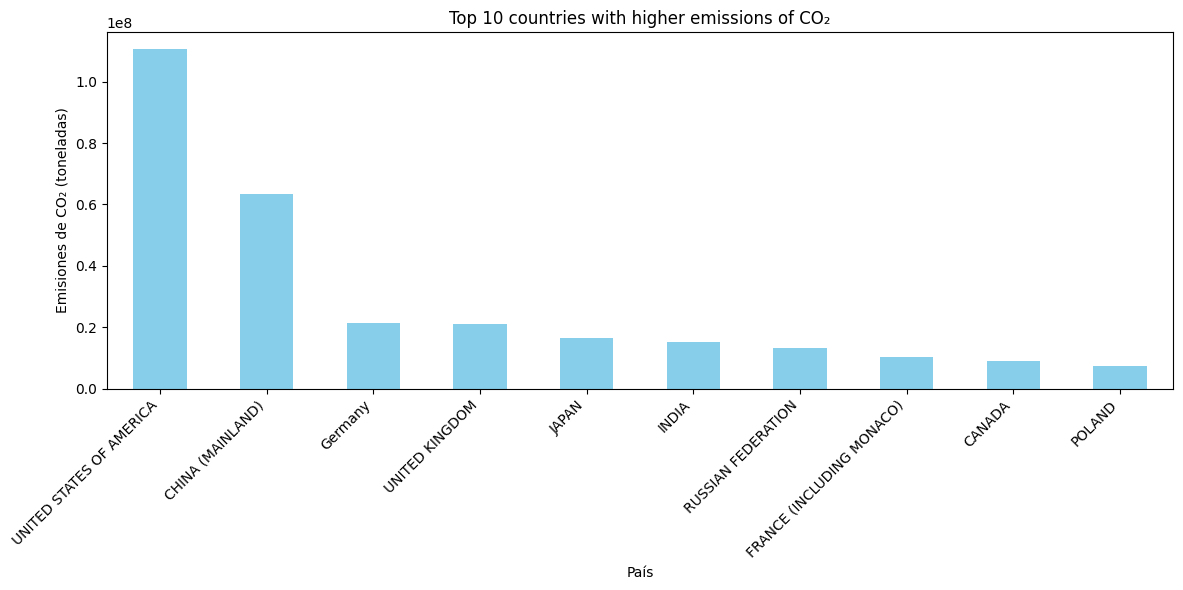

In [ ]:
#Plotting top10_c02
plt.figure(figsize=(12,6))
top10_c02.plot(kind="bar",color="skyblue")

plt.title("Top 10 countries with higher emissions of CO₂")
plt.xlabel("País")
plt.ylabel("Emisiones de CO₂ (toneladas)")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()


In [ ]:
#Filtering all rows for my top 10 conuntries with the most emission of C02.
top_10_c02 = (
    carbon_dioxide_df.groupby("Country")["Total"]
    .sum()
    .sort_values(ascending= False)
    .head(10)
)

# Sorting Original DF.
top_10_df = carbon_dioxide_df[carbon_dioxide_df["Country"].isin(top_10_c02.index)]

top_10_df =top_10_df.reset_index()
print(top_10_df.head())
print(top_10_df.shape)

   index  Year         Country  Total  Solid Fuel  Liquid Fuel  Gas Fuel  \
0      0  1751  UNITED KINGDOM   2552      2552.0          0.0       0.0   
1      1  1752  UNITED KINGDOM   2553      2553.0          0.0       0.0   
2      2  1753  UNITED KINGDOM   2553      2553.0          0.0       0.0   
3      3  1754  UNITED KINGDOM   2554      2554.0          0.0       0.0   
4      4  1755  UNITED KINGDOM   2555      2555.0          0.0       0.0   

   Cement  Gas Flaring  Per Capita  Bunker fuels (Not in Total)  
0     0.0          NaN         NaN                          0.0  
1     0.0          NaN         NaN                          0.0  
2     0.0          NaN         NaN                          0.0  
3     0.0          NaN         NaN                          0.0  
4     0.0          NaN         NaN                          0.0  
(1764, 11)


Index(['Solid Fuel', 'Liquid Fuel', 'Gas Fuel', 'Cement', 'Gas Flaring',
       'Per Capita', 'Bunker fuels (Not in Total)'],
      dtype='object')


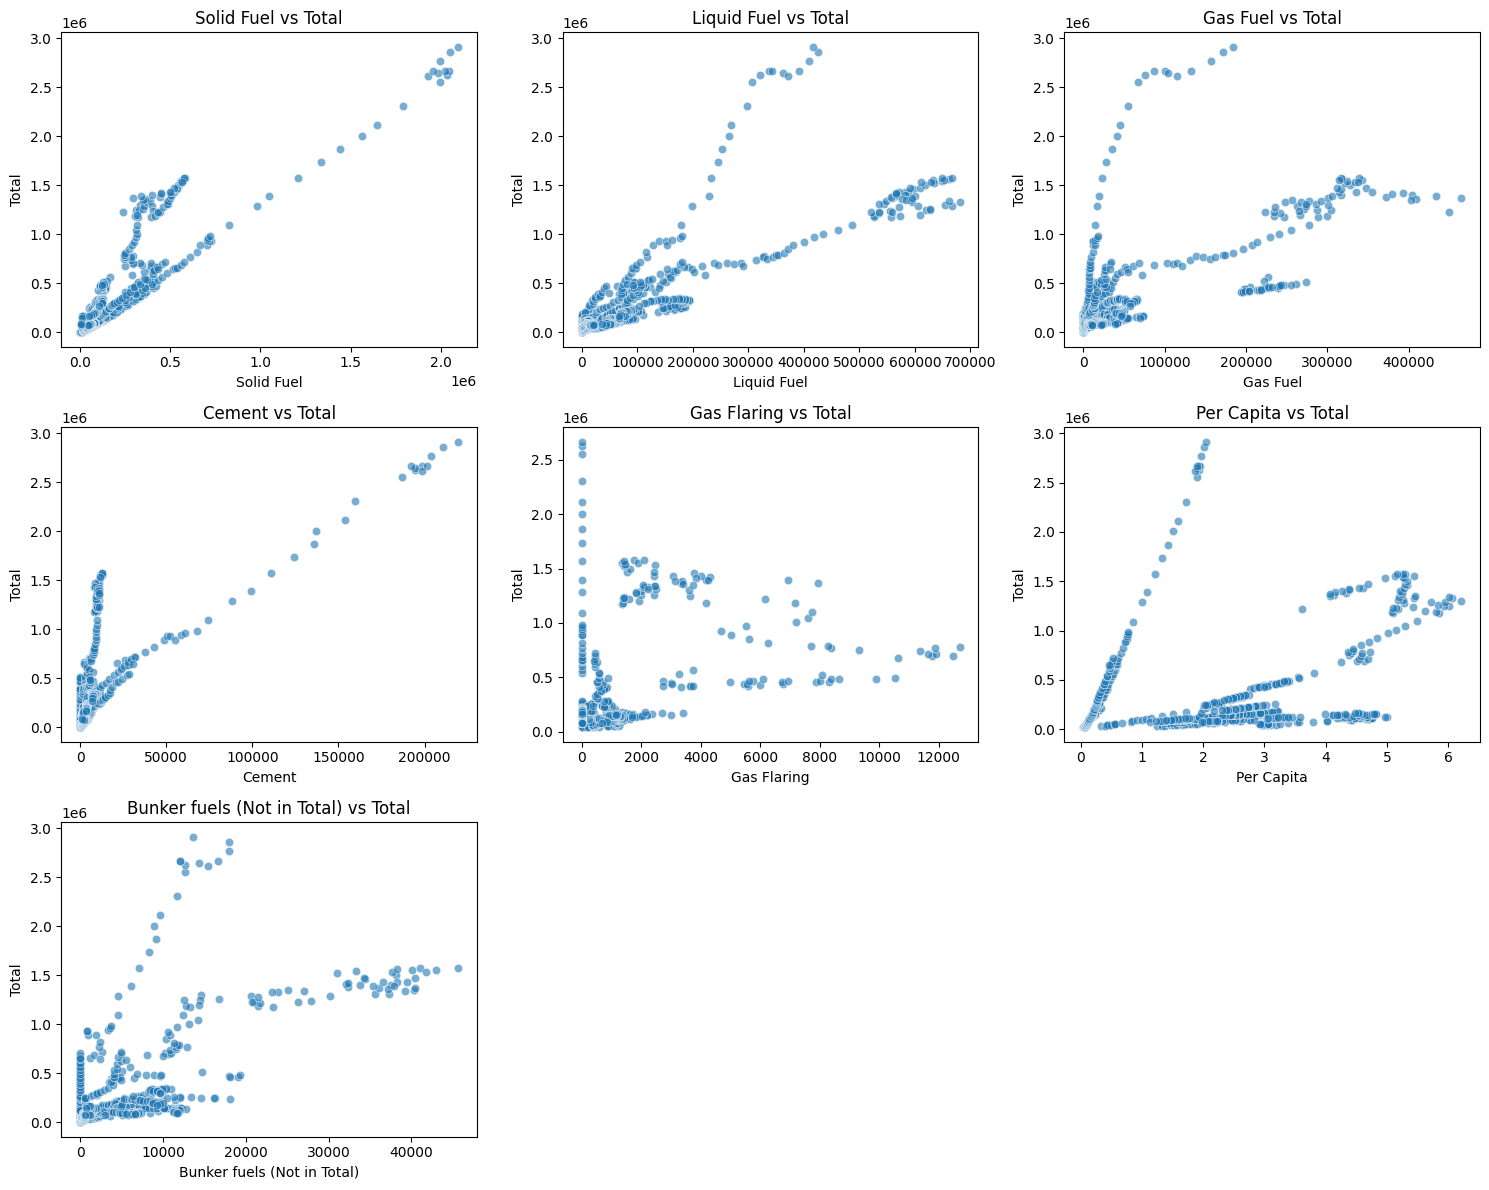

In [ ]:
#Exploring Relationship of Variables with Target Variable "Total"
features = (top_10_df.columns[4:])
print(features)
target = "Total"

#Polotting scatterplots grid
num_features = len(features)
cols = 3
rows = (num_features+ cols -1)//cols

plt.figure(figsize=(15,12))

for i, feature in enumerate(features, 1):
    plt.subplot(rows, cols, i)
    sns.scatterplot(data=top_10_df, x=feature, y=target, alpha=0.6)
    plt.title(f"{feature} vs {target}")
    plt.xlabel(feature)
    plt.ylabel(target)

plt.tight_layout()
plt.show()


The dataset shows multiple linear patterns when plotting each feature against Total CO₂ emissions. This is likely driven by:
- Large outliers such as the USA and China, whose emission scales dominate the distribution.
- Country‑specific emission behaviors, where each nation follows its own linear trend, creating parallel lines or clusters in scatterplots.
- Potential missing values or inconsistencies in some emission components, which may distort linear relationships.
- The model may require encoding categorical variables such as Country and Year to avoid forcing the model to learn a single global pattern.
- One‑hot encoding Country helps the model capture country‑specific emission structures.
- Encoding Year (or using it as a numeric trend variable) helps separate temporal effects from structural differences across countries.

All emission components (solid fuel, liquid fuel, gas fuel, cement, flaring) are parts of the Total, so they are naturally correlated.
This affects linear models and may require:
- regularization (Ridge/Lasso)
- dropping redundant features
- or using tree‑based models that handle multicollinearity well.


Plotting Solid Fuel vs Total


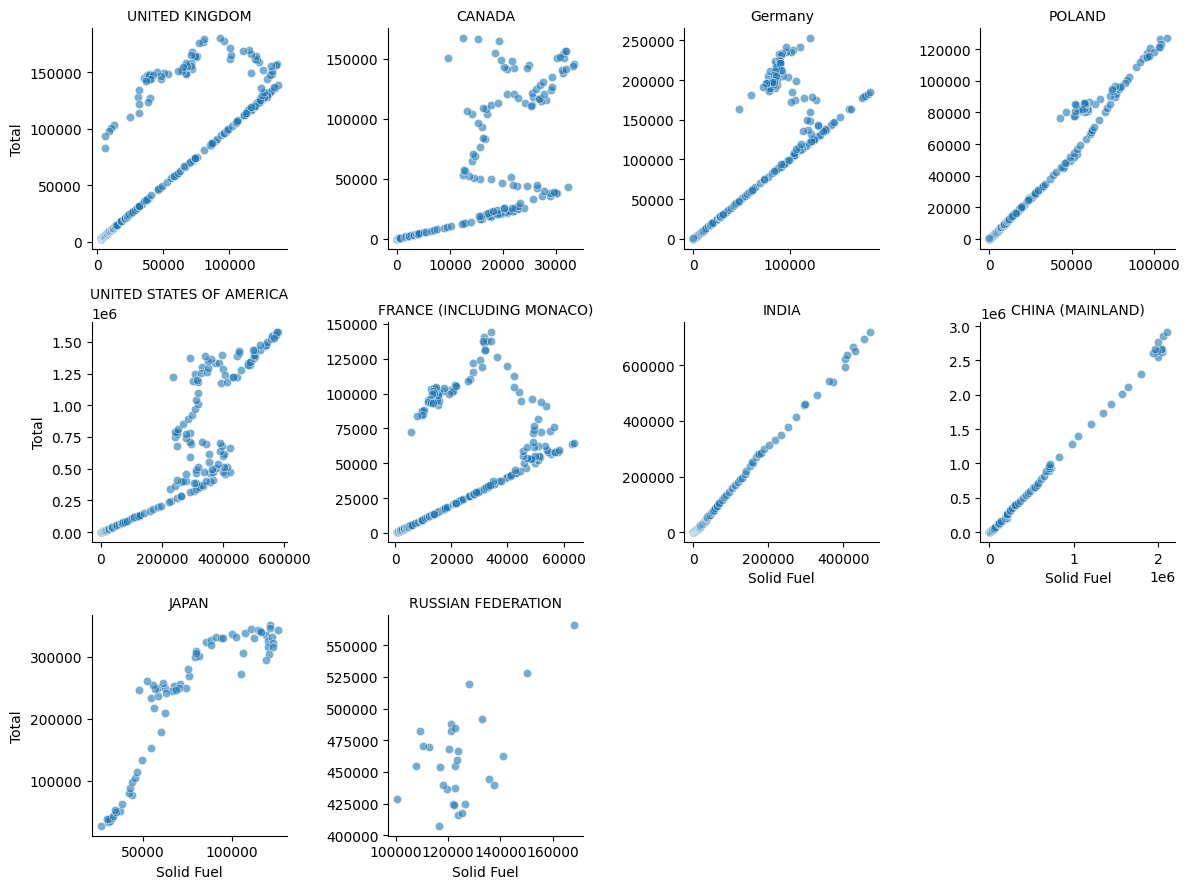

Plotting Liquid Fuel vs Total


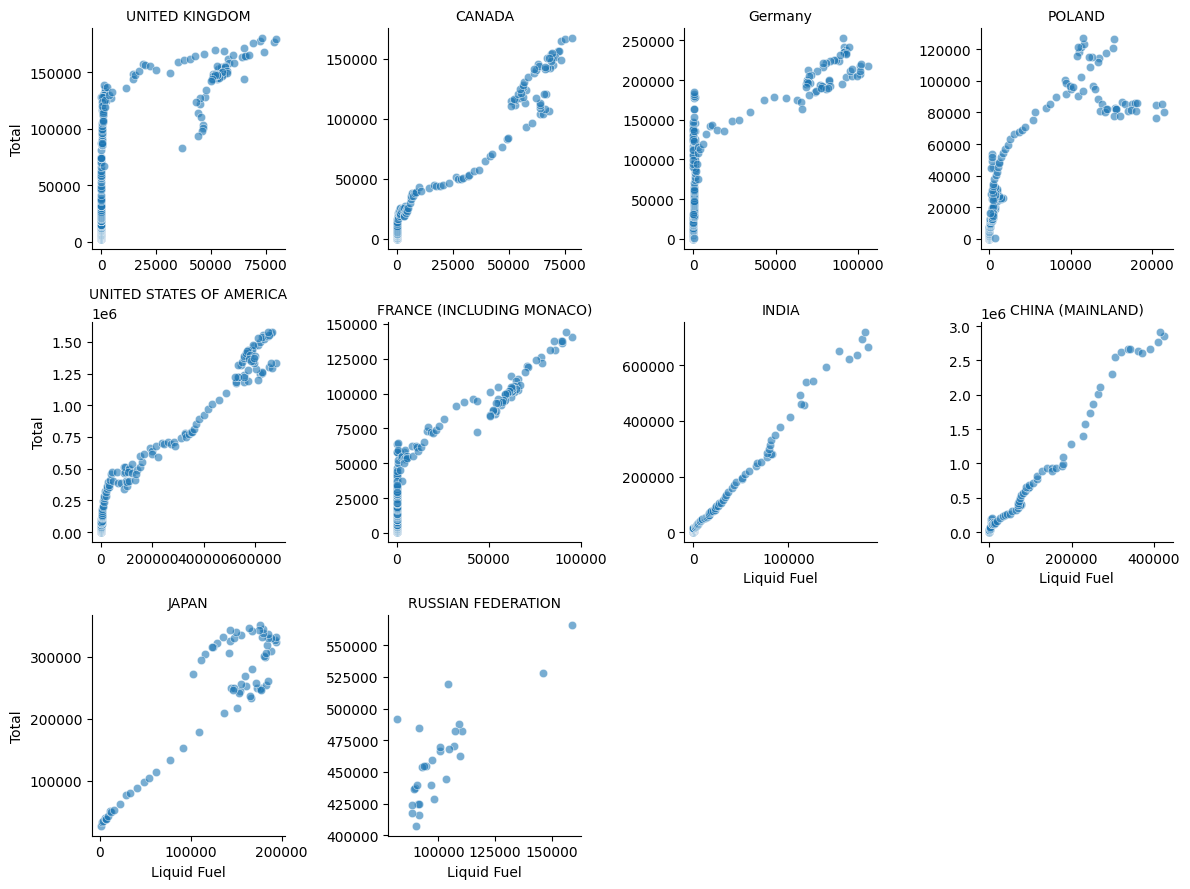

Plotting Gas Fuel vs Total


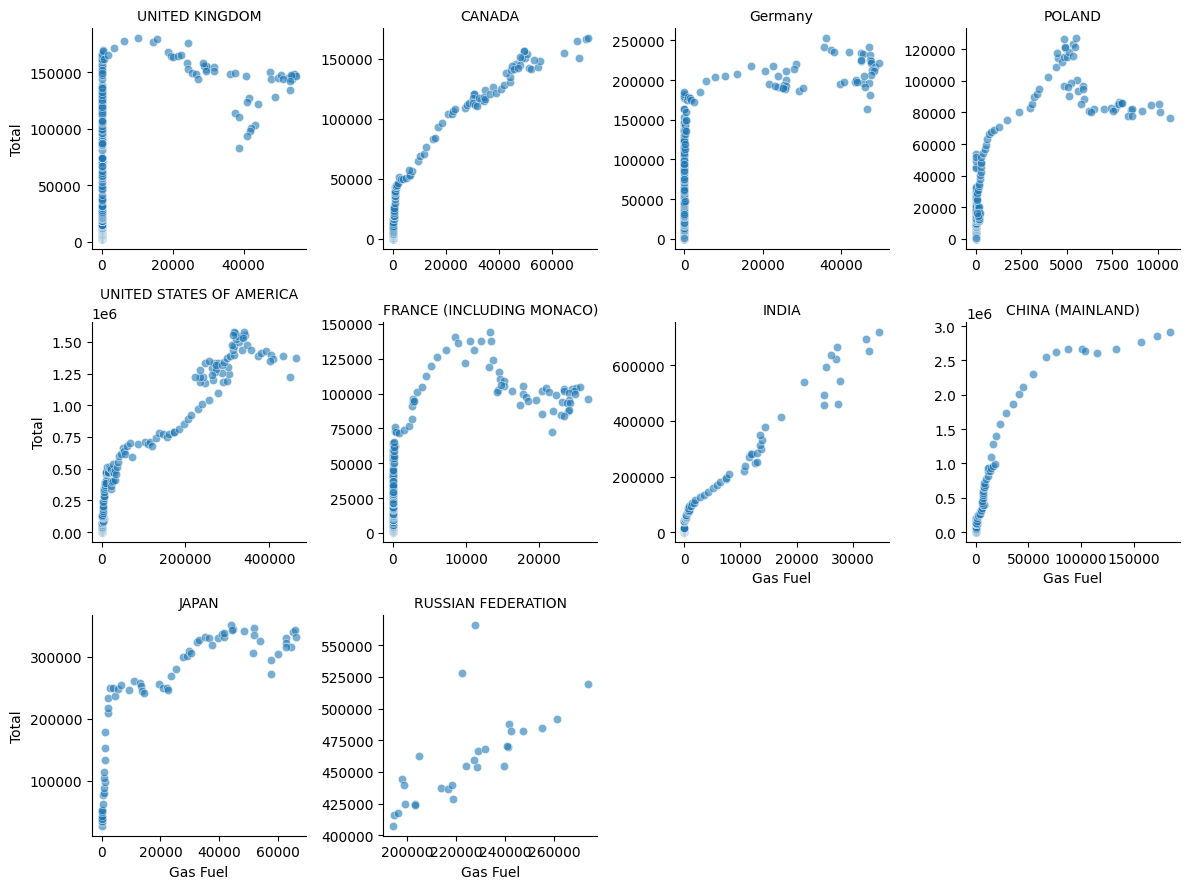

Plotting Cement vs Total


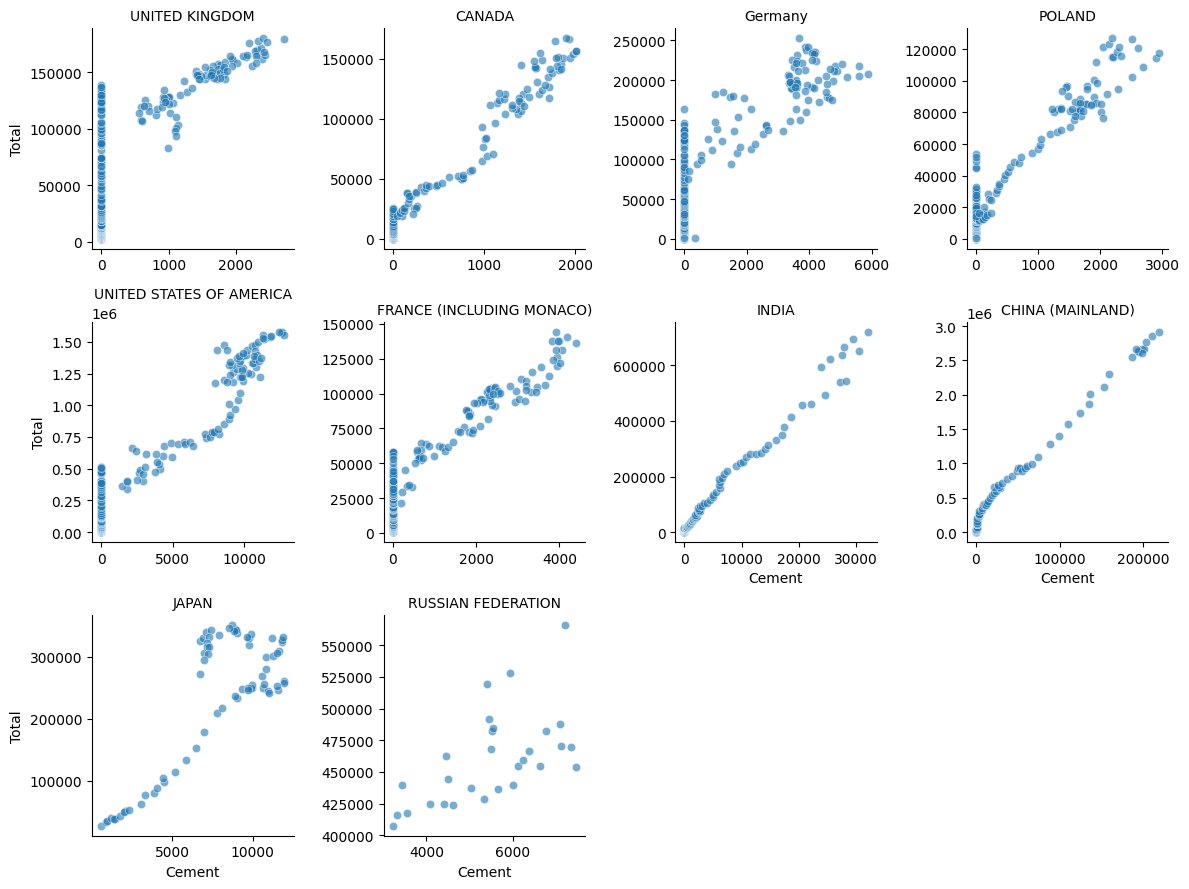

Plotting Gas Flaring vs Total


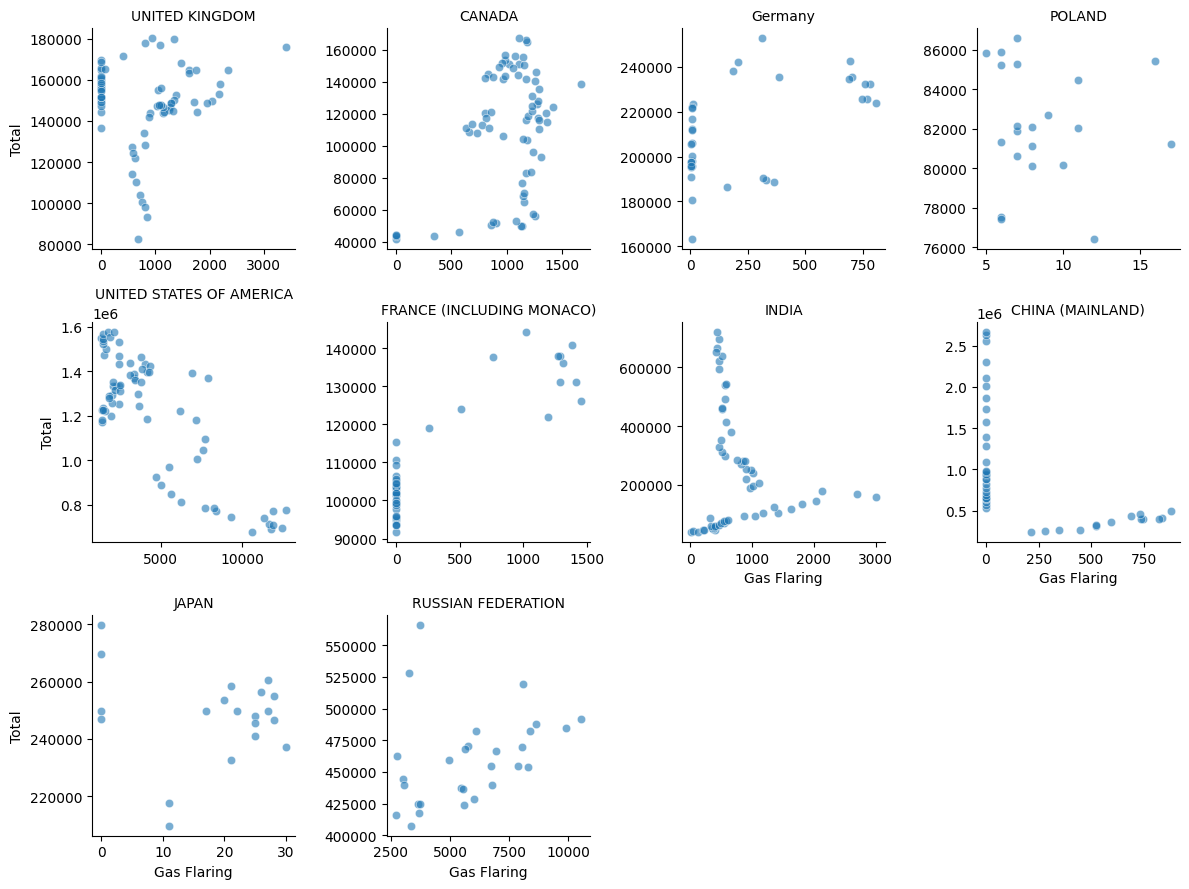

Plotting Per Capita vs Total


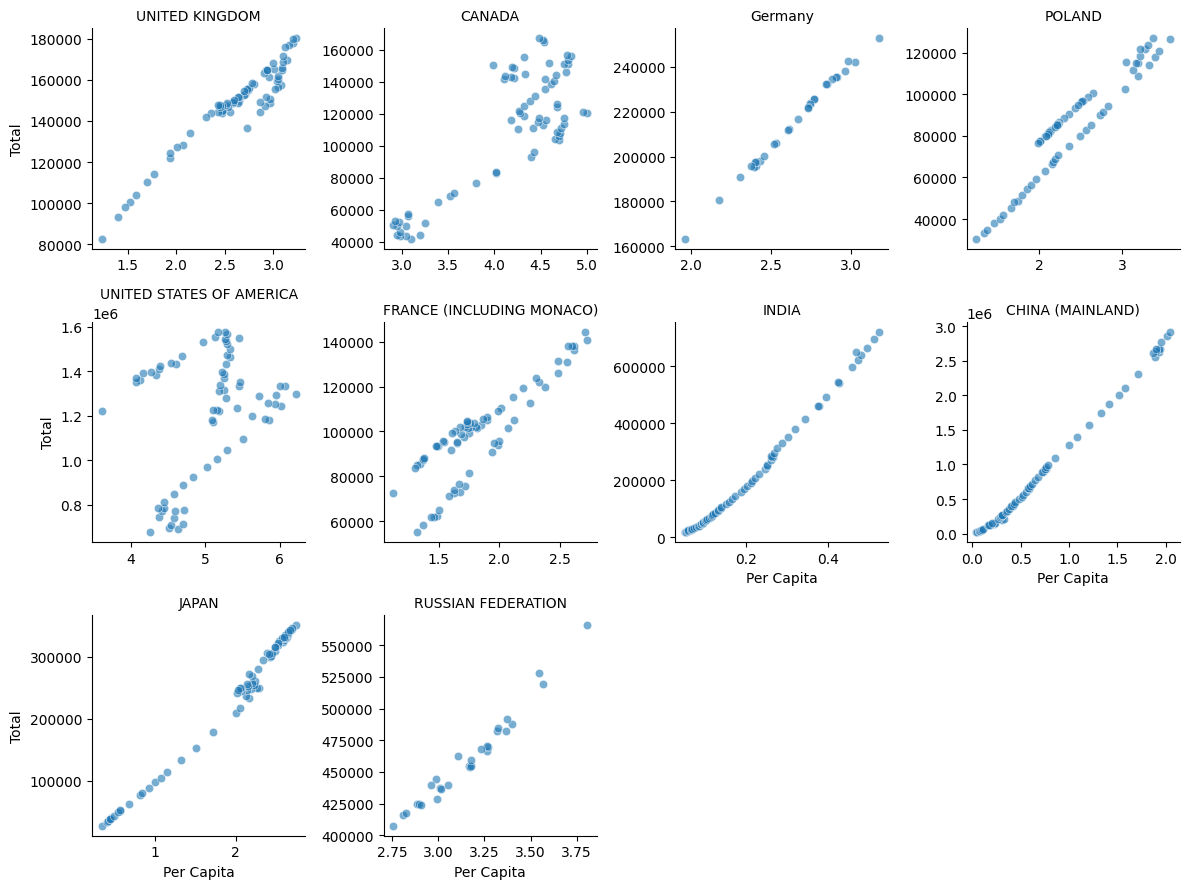

Plotting Bunker fuels (Not in Total) vs Total


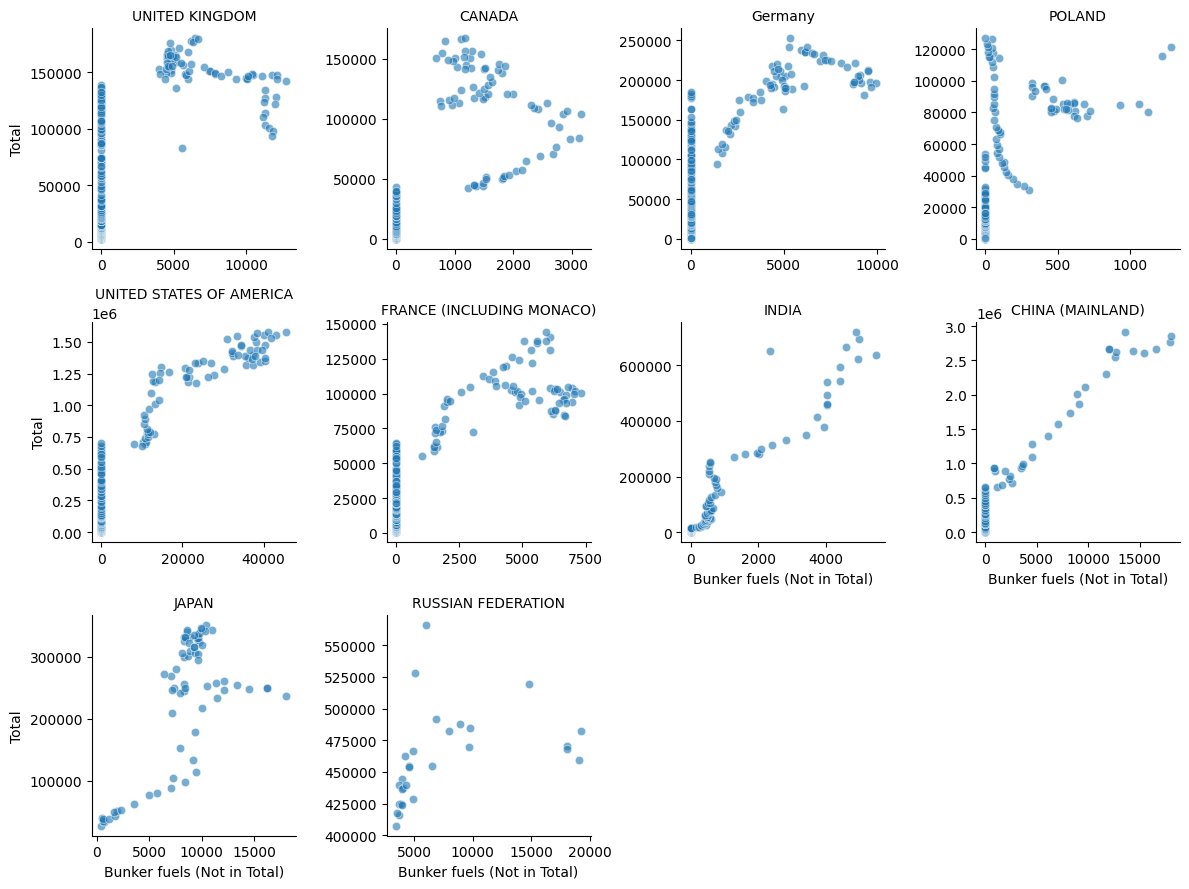

In [ ]:
features = top_10_df.columns[4:]
target = "Total"

for feature in features:
    print(f"Plotting {feature} vs {target}")

    g = sns.FacetGrid(top_10_df, col="Country", col_wrap=4, height=3,
                      sharex=False, sharey=False)
    g.map_dataframe(sns.scatterplot, x=feature, y=target, alpha=0.6)

    g.set_titles("{col_name}")
    g.set_axis_labels(feature, target)

    plt.tight_layout()
    plt.show()

-Check nan values per clumn per country.
- Include heatmpa to check how strong is the varibales correlated with one another related to total by ountry
- Decide if adding growth population rate GDP or other variables.

### Use this dataset girls: top_10_df.

##Random forest

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import pickle
import warnings
warnings.filterwarnings('ignore')

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
pd.set_option('display.max_columns', None)

print("Libraries imported!")

Libraries imported!


In [ ]:
# Load dataset
carbon_dioxide_df = pd.read_csv("fossil-fuel-co2-emissions-by-nation.csv")

# Remove USSR
carbon_dioxide_df = carbon_dioxide_df[carbon_dioxide_df["Country"] != "USSR"]

#Adding Germany Together:
mask = carbon_dioxide_df["Country"].str.contains("Germany", case=False, na=False)
carbon_dioxide_df.loc[mask, "Country"] = "Germany"

# Get top 10 countries by total emissions
top_10_c02 = (
    carbon_dioxide_df.groupby("Country")["Total"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

# Filter to top 10 countries
top_10_df = carbon_dioxide_df[carbon_dioxide_df["Country"].isin(top_10_c02.index)]
top_10_df = top_10_df.reset_index(drop=True)

print("✓ Data loaded!")
print(f"  Shape: {top_10_df.shape}")
print(f"  Top 10 countries: {list(top_10_c02.index)}")
print(f"  Year range: {top_10_df['Year'].min()} - {top_10_df['Year'].max()}")

✓ Data loaded!
  Shape: (1764, 10)
  Top 10 countries: ['UNITED STATES OF AMERICA', 'CHINA (MAINLAND)', 'Germany', 'UNITED KINGDOM', 'JAPAN', 'INDIA', 'RUSSIAN FEDERATION', 'FRANCE (INCLUDING MONACO)', 'CANADA', 'POLAND']
  Year range: 1751 - 2020


In [ ]:
# Check data types
print("\n1. Data types:")
print(top_10_df.dtypes)

# Check missing values
print("\n2. Missing values:")
missing_summary = pd.DataFrame({
    'Missing': top_10_df.isnull().sum(),
    'Percentage': (top_10_df.isnull().sum() / len(top_10_df)) * 100
})
print(missing_summary[missing_summary['Missing'] > 0])

# Handle missing values
print("\n3. Handling missing values...")

# Fill emission columns with 0 (no emissions from that source)
emission_cols = ['Solid Fuel', 'Liquid Fuel', 'Gas Fuel', 'Cement',
                 'Gas Flaring', 'Bunker fuels (Not in Total)']
for col in emission_cols:
    if col in top_10_df.columns:
        top_10_df[col] = top_10_df[col].fillna(0)

# Fill Per Capita with country median
if 'Per Capita' in top_10_df.columns:
    top_10_df['Per Capita'] = top_10_df.groupby('Country')['Per Capita'].transform(
        lambda x: x.fillna(x.median())
    )
    top_10_df['Per Capita'] = top_10_df['Per Capita'].fillna(top_10_df['Per Capita'].median())

# Drop rows with missing Total (target)
top_10_df = top_10_df.dropna(subset=['Total'])

print(f"   Missing values after cleaning: {top_10_df.isnull().sum().sum()}")

# temporal filtering to 1970-2020 (as per the research)
print("\n4. Filtering to 1970-2020...")
top_10_df = top_10_df[(top_10_df['Year'] >= 1970) & (top_10_df['Year'] <= 2020)]
print(f"   Shape after filtering: {top_10_df.shape}")

# Sort by Country and Year
top_10_df = top_10_df.sort_values(['Country', 'Year']).reset_index(drop=True)

print("\n Data cleaning complete!")



1. Data types:
Year                             int64
Country                         object
Total                            int64
Solid Fuel                     float64
Liquid Fuel                    float64
Gas Fuel                       float64
Cement                         float64
Gas Flaring                    float64
Per Capita                     float64
Bunker fuels (Not in Total)    float64
dtype: object

2. Missing values:
             Missing  Percentage
Solid Fuel         1    0.056689
Liquid Fuel        1    0.056689
Gas Fuel          12    0.680272
Gas Flaring     1302   73.809524
Per Capita      1137   64.455782

3. Handling missing values...
   Missing values after cleaning: 0

4. Filtering to 1970-2020...
   Shape after filtering: (488, 10)

 Data cleaning complete!


In [ ]:
df_features = top_10_df.copy()

print("\n1. Time-based features...")
df_features['Year_Normalized'] = (df_features['Year'] - 1970) / 50  # Scale 0-1
df_features['Years_Since_1970'] = df_features['Year'] - 1970
df_features['Decade'] = (df_features['Year'] // 10) * 10

print("\n2. Emission composition features...")
# Ratios (avoid division by zero)
df_features['Solid_Fuel_Ratio'] = df_features['Solid Fuel'] / (df_features['Total'] + 1e-10)
df_features['Liquid_Fuel_Ratio'] = df_features['Liquid Fuel'] / (df_features['Total'] + 1e-10)
df_features['Gas_Fuel_Ratio'] = df_features['Gas Fuel'] / (df_features['Total'] + 1e-10)
df_features['Cement_Ratio'] = df_features['Cement'] / (df_features['Total'] + 1e-10)
df_features['Total_Fossil_Fuels'] = (df_features['Solid Fuel'] +
                                      df_features['Liquid Fuel'] +
                                      df_features['Gas Fuel'])

print("\n3. Lag features (1, 2, 3 years)...")
for lag in [1, 2, 3]:
    df_features[f'Total_Lag_{lag}'] = df_features.groupby('Country')['Total'].shift(lag)
    df_features[f'Solid_Fuel_Lag_{lag}'] = df_features.groupby('Country')['Solid Fuel'].shift(lag)

print("\n4. Rolling statistics...")
for window in [3, 5]:
    df_features[f'Total_Rolling_Mean_{window}y'] = df_features.groupby('Country')['Total'].transform(
        lambda x: x.rolling(window=window, min_periods=1).mean()
    )
    df_features[f'Total_Rolling_Std_{window}y'] = df_features.groupby('Country')['Total'].transform(
        lambda x: x.rolling(window=window, min_periods=1).std()
    )

print("\n5. Growth rate features...")
df_features['Total_Growth_Rate'] = df_features.groupby('Country')['Total'].pct_change()
df_features['Total_Growth_Rate'] = df_features['Total_Growth_Rate'].replace([np.inf, -np.inf], np.nan)

print("\n6. Country-level features...")
country_stats = df_features.groupby('Country')['Total'].agg([
    ('Country_Mean_Emissions', 'mean'),
    ('Country_Std_Emissions', 'std'),
    ('Country_Max_Emissions', 'max')
]).reset_index()
df_features = df_features.merge(country_stats, on='Country', how='left')

print("\n7. Encoding Country...")
le = LabelEncoder()
df_features['Country_Encoded'] = le.fit_transform(df_features['Country'])

# Save encoder
with open('country_encoder.pkl', 'wb') as f:
    pickle.dump(le, f)

print("\n8. Handling missing values from feature engineering...")
df_features = df_features.groupby('Country').fillna(method='ffill').fillna(method='bfill')
df_features = df_features.fillna(0)

print(f"\n✓ Feature engineering complete!")
print(f"  Total features: {len(df_features.columns)}")
print(f"  Missing values: {df_features.isnull().sum().sum()}")


1. Time-based features...

2. Emission composition features...

3. Lag features (1, 2, 3 years)...

4. Rolling statistics...

5. Growth rate features...

6. Country-level features...

7. Encoding Country...

8. Handling missing values from feature engineering...

✓ Feature engineering complete!
  Total features: 32
  Missing values: 0


In [ ]:
# Define target and features
target_col = 'Total'
y = df_features[target_col]

exclude_cols = ['Country', 'Total', 'Per Capita', 'Bunker fuels (Not in Total)']
feature_cols = [col for col in df_features.columns if col not in exclude_cols]
X = df_features[feature_cols]

print(f"\nTarget: {target_col}")
print(f"Number of features: {len(feature_cols)}")

# Time-based split
print("\nTime-based split:")
print("  Training: 1970-2010")
print("  Validation: 2011-2015")
print("  Test: 2016-2020")

train_mask = df_features['Year'] <= 2010
val_mask = (df_features['Year'] > 2010) & (df_features['Year'] <= 2015)
test_mask = df_features['Year'] > 2015

X_train = X[train_mask]
y_train = y[train_mask]
X_val = X[val_mask]
y_val = y[val_mask]
X_test = X[test_mask]
y_test = y[test_mask]

print(f"\nSplit sizes:")
print(f"  Training: {len(X_train):,} samples ({len(X_train)/len(X)*100:.1f}%)")
print(f"  Validation: {len(X_val):,} samples ({len(X_val)/len(X)*100:.1f}%)")
print(f"  Test: {len(X_test):,} samples ({len(X_test)/len(X)*100:.1f}%)")

# Scale features
print("\nScaling features...")
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=feature_cols,
    index=X_train.index
)
X_val_scaled = pd.DataFrame(
    scaler.transform(X_val),
    columns=feature_cols,
    index=X_val.index
)
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test),
    columns=feature_cols,
    index=X_test.index
)

# Save scaler
with open('feature_scaler_rf.pkl', 'wb') as f:
    pickle.dump(scaler, f)

print("\n Data split and scaling complete!")


Target: Total
Number of features: 29

Time-based split:
  Training: 1970-2010
  Validation: 2011-2015
  Test: 2016-2020

Split sizes:
  Training: 388 samples (79.5%)
  Validation: 50 samples (10.2%)
  Test: 50 samples (10.2%)

Scaling features...

 Data split and scaling complete!


In [ ]:
# OPTIMIZED parameter grid (faster, still good performance)
param_dist_rf = {
    'n_estimators': [100, 200, 300],  # Reduced from [100, 200, 300, 500]
    'max_depth': [20, 30, None],  # Reduced from [10, 20, 30, 40, None]
    'min_samples_split': [2, 5],  # Reduced from [2, 5, 10]
    'min_samples_leaf': [1, 2],  # Reduced from [1, 2, 4]
    'max_features': ['sqrt', 'log2'],  # Removed None for speed
    'bootstrap': [True]  # Only True (faster)
}

print("\n1. Parameter grid (optimized for speed):")
for param, values in param_dist_rf.items():
    print(f"   {param}: {values}")

# Initialize Random Forest
rf = RandomForestRegressor(
    random_state=42,
    n_jobs=-1,  # Use all CPU cores
    warm_start=False,
    oob_score=False
)

# RandomizedSearchCV with fewer iterations
print("\n2. Running RandomizedSearchCV...")
print("   (This will take 2-5 minutes...)")

random_search_rf = RandomizedSearchCV(
    rf,
    param_dist_rf,
    n_iter=15,  # Reduced from 20 for speed
    cv=3,  # Reduced from 5 for speed
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    verbose=2,
    random_state=42
)

# Train
random_search_rf.fit(X_train_scaled, y_train)

print("\n3. Best parameters found:")
best_params = random_search_rf.best_params_
for param, value in best_params.items():
    print(f"   {param}: {value}")

# Get best model
best_rf = random_search_rf.best_estimator_

# Make predictions
print("\n4. Making predictions...")
y_train_pred = best_rf.predict(X_train_scaled)
y_val_pred = best_rf.predict(X_val_scaled)
y_test_pred = best_rf.predict(X_test_scaled)

# Calculate metrics
def calculate_metrics(y_true, y_pred, dataset_name):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)

    print(f"\n   {dataset_name}:")
    print(f"   - RMSE: {rmse:.4f}")
    print(f"   - MAE: {mae:.4f}")
    print(f"   - R²: {r2:.4f}")

    return {'RMSE': rmse, 'MAE': mae, 'R2': r2}

print("\n5. Model Performance:")
metrics_rf = {
    'train': calculate_metrics(y_train, y_train_pred, 'Training'),
    'val': calculate_metrics(y_val, y_val_pred, 'Validation'),
    'test': calculate_metrics(y_test, y_test_pred, 'Test')
}

# Save model
with open('random_forest_optimized.pkl', 'wb') as f:
    pickle.dump(best_rf, f)

print("\n✓ Random Forest training complete!")
print("✓ Model saved as 'random_forest_optimized.pkl'")


1. Parameter grid (optimized for speed):
   n_estimators: [100, 200, 300]
   max_depth: [20, 30, None]
   min_samples_split: [2, 5]
   min_samples_leaf: [1, 2]
   max_features: ['sqrt', 'log2']
   bootstrap: [True]

2. Running RandomizedSearchCV...
   (This will take 2-5 minutes...)
Fitting 3 folds for each of 15 candidates, totalling 45 fits

3. Best parameters found:
   n_estimators: 100
   min_samples_split: 2
   min_samples_leaf: 1
   max_features: sqrt
   max_depth: 20
   bootstrap: True

4. Making predictions...

5. Model Performance:

   Training:
   - RMSE: 9050.2000
   - MAE: 3327.8065
   - R²: 0.9996

   Validation:
   - RMSE: 170887.1983
   - MAE: 62642.6036
   - R²: 0.9514

   Test:
   - RMSE: 237834.9202
   - MAE: 89811.8234
   - R²: 0.9132

✓ Random Forest training complete!
✓ Model saved as 'random_forest_optimized.pkl'



Top 15 Most Important Features:
               Feature  Importance
 Total_Rolling_Mean_3y    0.196873
 Total_Rolling_Mean_5y    0.156593
           Total_Lag_3    0.147769
           Total_Lag_2    0.098377
           Total_Lag_1    0.089591
    Total_Fossil_Fuels    0.086238
           Liquid Fuel    0.044259
            Solid Fuel    0.036102
      Solid_Fuel_Lag_1    0.035706
      Solid_Fuel_Lag_3    0.022961
Country_Mean_Emissions    0.022539
      Solid_Fuel_Lag_2    0.014776
              Gas Fuel    0.009212
       Country_Encoded    0.008218
          Cement_Ratio    0.006408


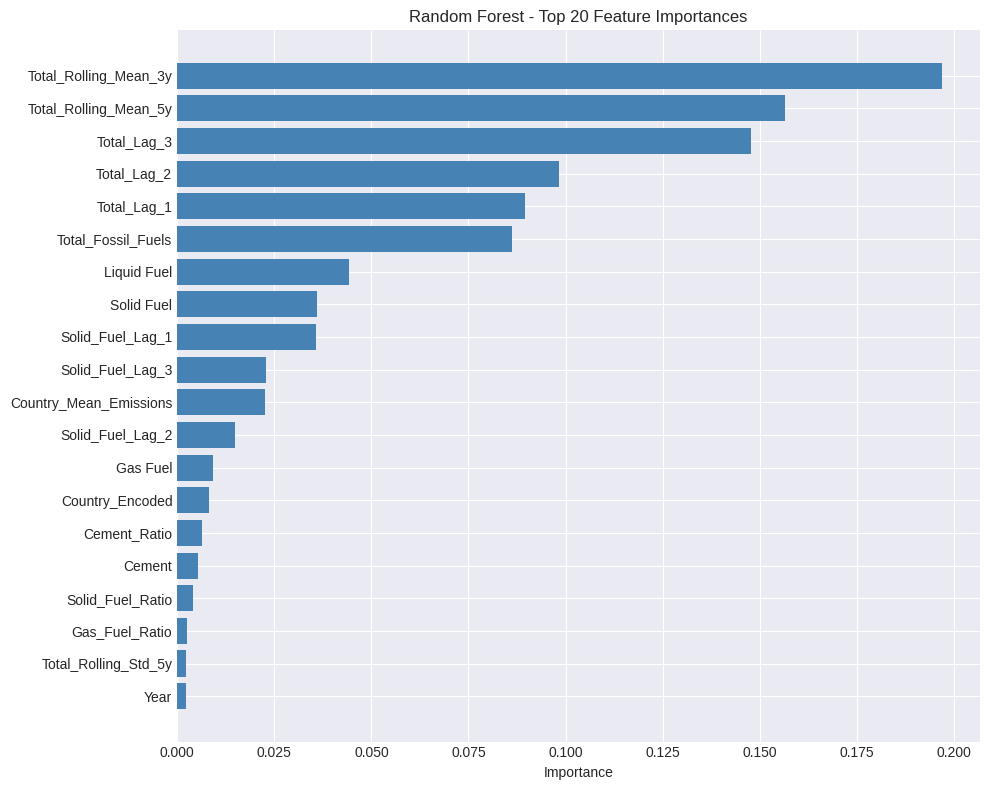


✓ Feature importance saved!


In [ ]:
# Get feature importance
feature_importance = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': best_rf.feature_importances_
}).sort_values('Importance', ascending=False)

print("\nTop 15 Most Important Features:")
print(feature_importance.head(15).to_string(index=False))

# Plot top 15 features
plt.figure(figsize=(10, 8))
top_features = feature_importance.head(20)
plt.barh(range(len(top_features)), top_features['Importance'], color='steelblue')
plt.yticks(range(len(top_features)), top_features['Feature'])
plt.xlabel('Importance')
plt.title('Random Forest - Top 20 Feature Importances')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('rf_feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()

# Save feature importance
feature_importance.to_csv('rf_feature_importance.csv', index=False)

print("\n✓ Feature importance saved!")

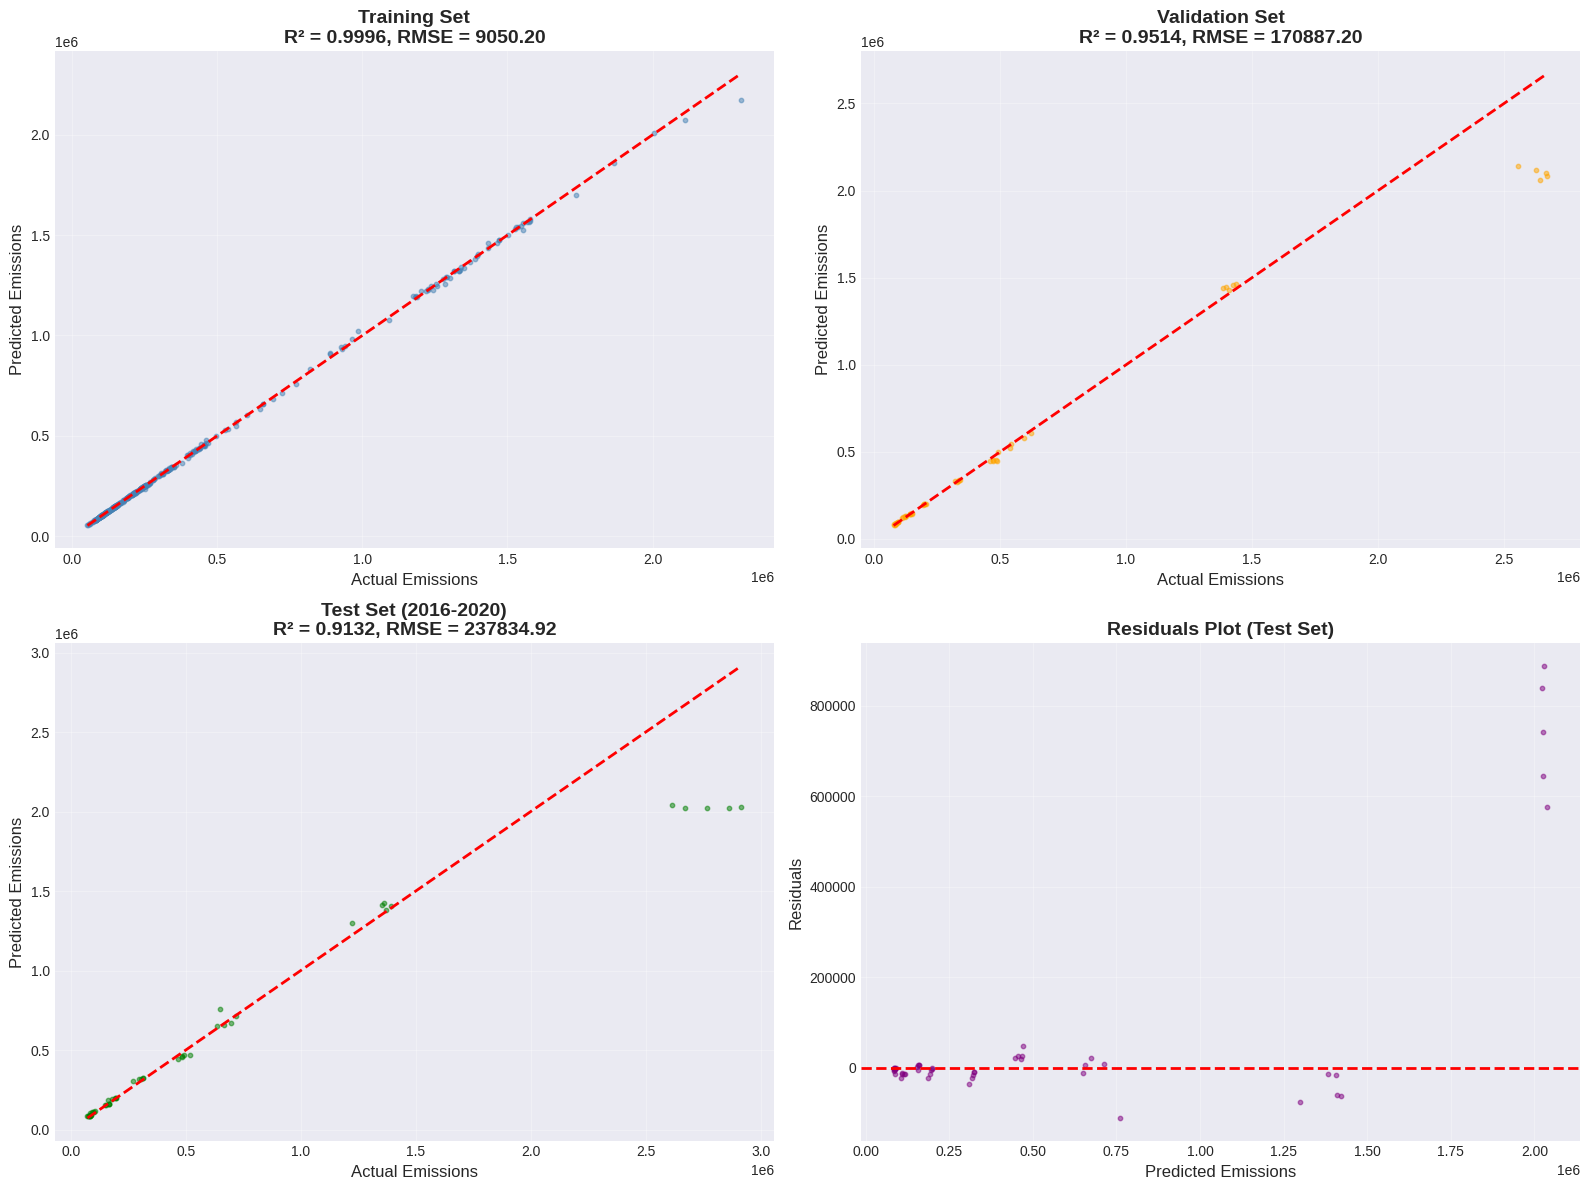


✓ Visualizations created and saved!


In [ ]:
# Create comprehensive visualization
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Training predictions
ax1 = axes[0, 0]
ax1.scatter(y_train, y_train_pred, alpha=0.5, s=10, color='steelblue')
ax1.plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 'r--', lw=2)
ax1.set_xlabel('Actual Emissions', fontsize=12)
ax1.set_ylabel('Predicted Emissions', fontsize=12)
ax1.set_title(f'Training Set\nR² = {metrics_rf["train"]["R2"]:.4f}, RMSE = {metrics_rf["train"]["RMSE"]:.2f}',
              fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3)

# 2. Validation predictions
ax2 = axes[0, 1]
ax2.scatter(y_val, y_val_pred, alpha=0.5, s=10, color='orange')
ax2.plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], 'r--', lw=2)
ax2.set_xlabel('Actual Emissions', fontsize=12)
ax2.set_ylabel('Predicted Emissions', fontsize=12)
ax2.set_title(f'Validation Set\nR² = {metrics_rf["val"]["R2"]:.4f}, RMSE = {metrics_rf["val"]["RMSE"]:.2f}',
              fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3)

# 3. Test predictions
ax3 = axes[1, 0]
ax3.scatter(y_test, y_test_pred, alpha=0.5, s=10, color='green')
ax3.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
ax3.set_xlabel('Actual Emissions', fontsize=12)
ax3.set_ylabel('Predicted Emissions', fontsize=12)
ax3.set_title(f'Test Set (2016-2020)\nR² = {metrics_rf["test"]["R2"]:.4f}, RMSE = {metrics_rf["test"]["RMSE"]:.2f}',
              fontsize=14, fontweight='bold')
ax3.grid(True, alpha=0.3)

# 4. Residuals plot
ax4 = axes[1, 1]
residuals = y_test - y_test_pred
ax4.scatter(y_test_pred, residuals, alpha=0.5, s=10, color='purple')
ax4.axhline(y=0, color='r', linestyle='--', lw=2)
ax4.set_xlabel('Predicted Emissions', fontsize=12)
ax4.set_ylabel('Residuals', fontsize=12)
ax4.set_title('Residuals Plot (Test Set)', fontsize=14, fontweight='bold')
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('rf_predictions_comprehensive.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Visualizations created and saved!")


Model Performance by Country (Test Set):
                           Mean_Error  Mean_Abs_Error  Mean_Pct_Error
Country                                                              
CHINA (MAINLAND)            738235.03       738235.03           26.56
UNITED STATES OF AMERICA    -45160.86        45160.86           -3.44
INDIA                       -17080.63        31900.73           -2.71
RUSSIAN FEDERATION           28158.67        28158.67            5.70
JAPAN                       -18541.46        18541.46           -6.36
UNITED KINGDOM              -14672.27        14672.27          -15.72
Germany                      -8637.41         8637.41           -5.00
CANADA                        3081.79         4927.84            1.81
FRANCE (INCLUDING MONACO)    -4778.24         4778.24           -6.20
POLAND                       -3105.72         3105.72           -3.94


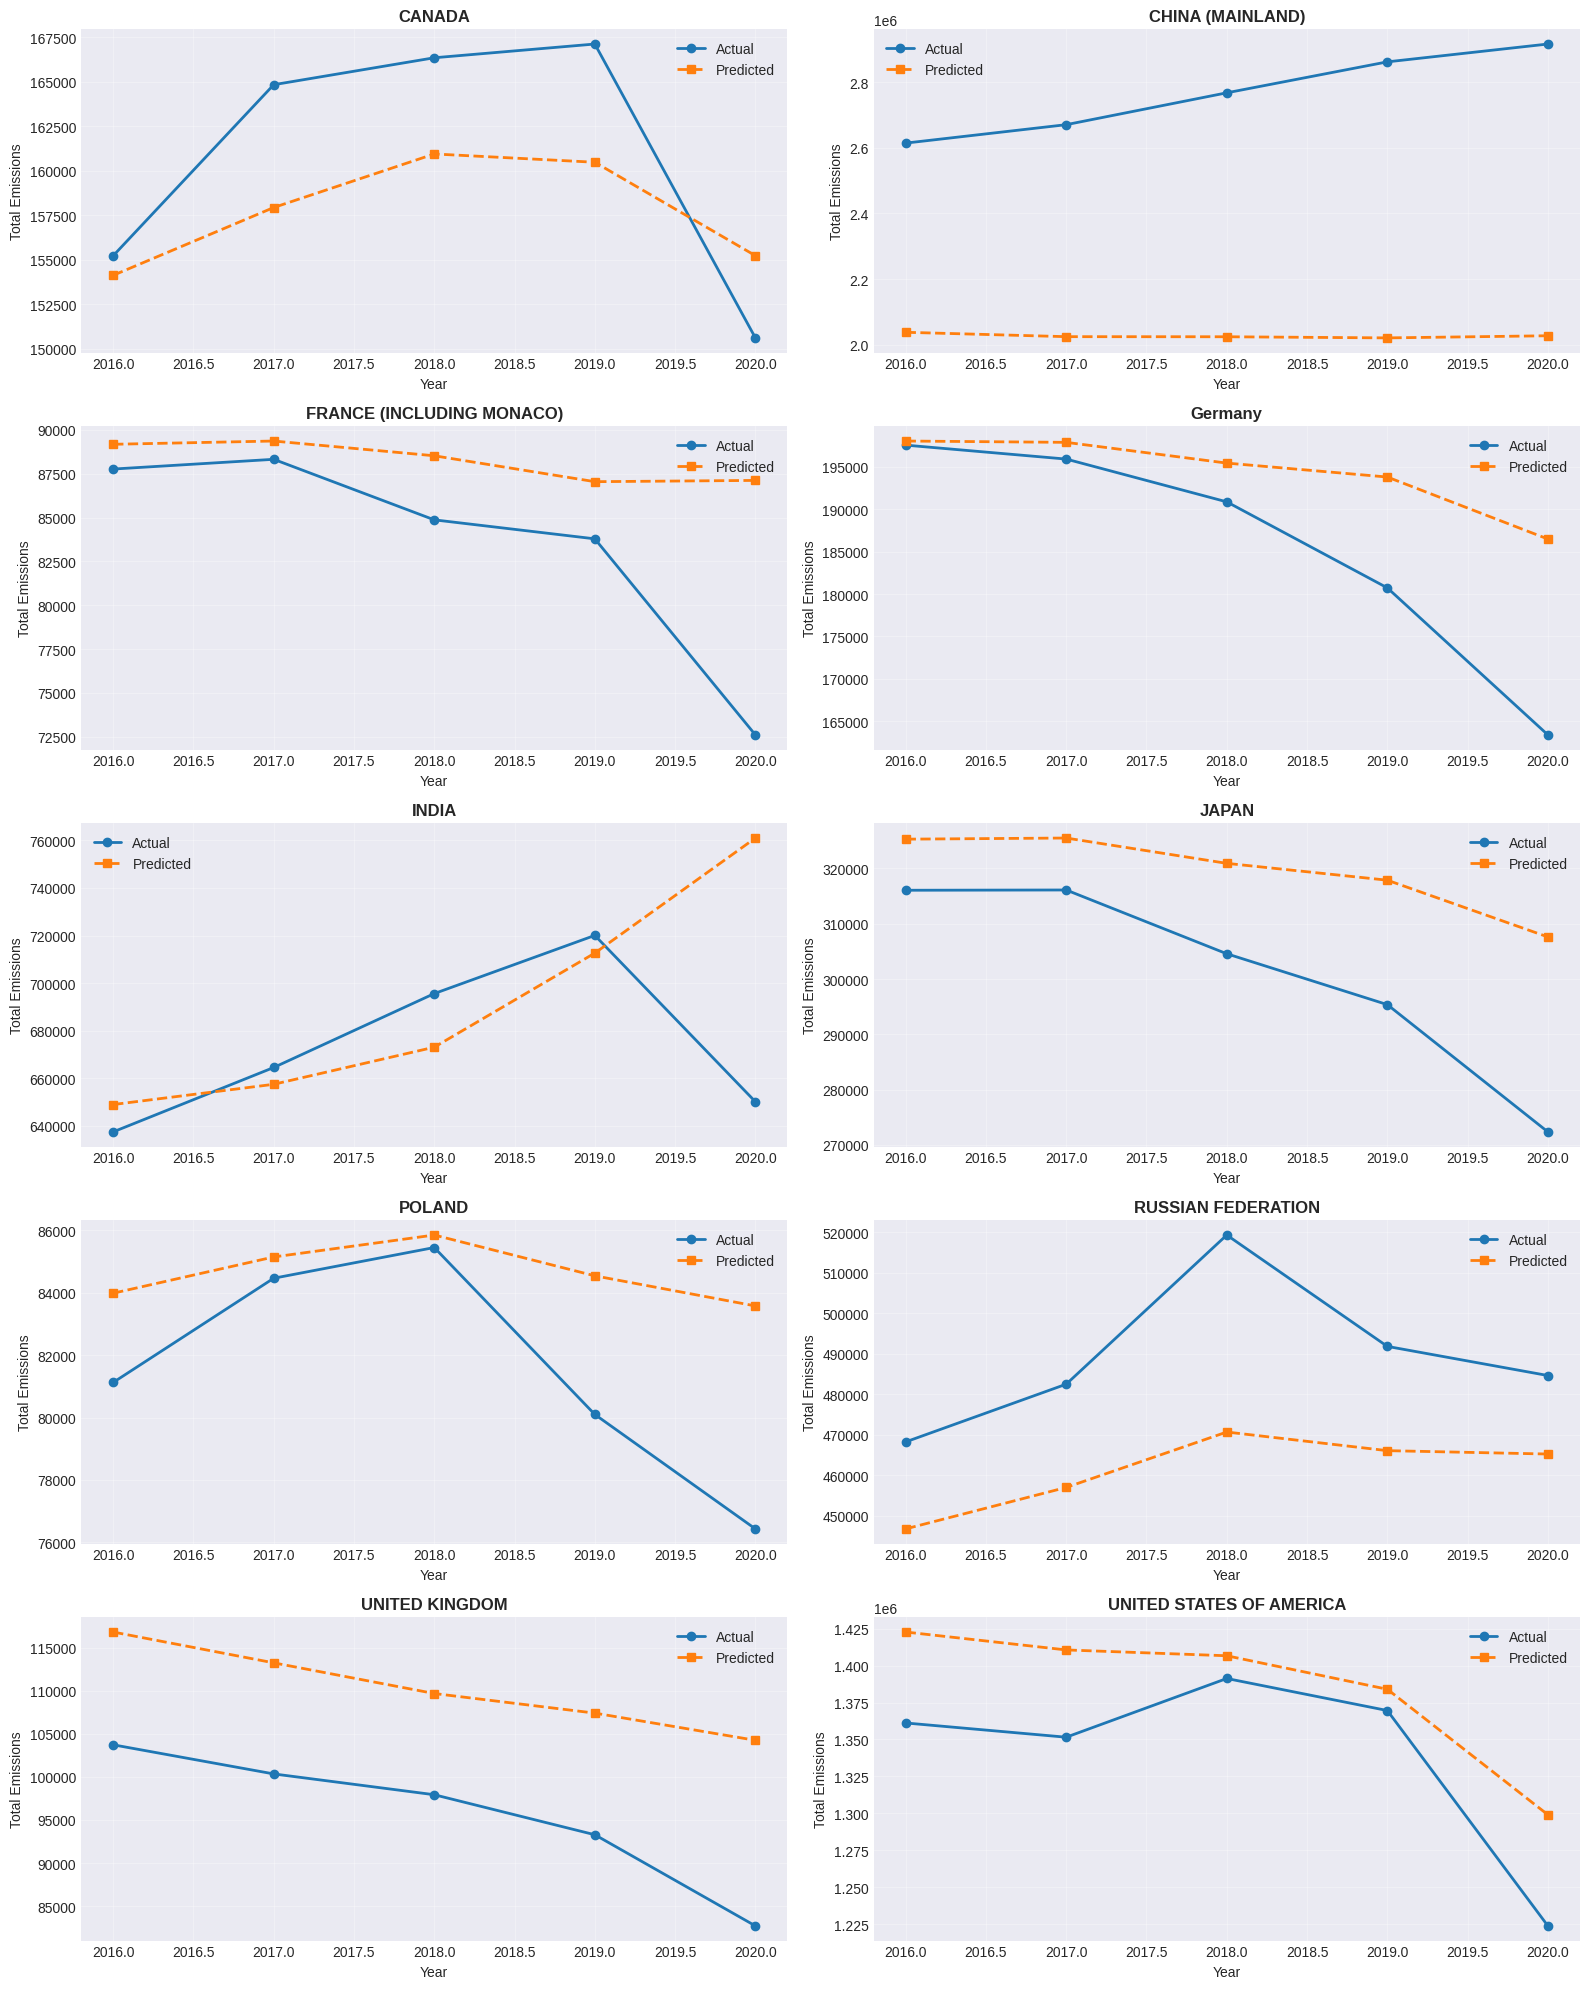


✓ Country-level analysis complete!
✓ Predictions saved as 'rf_test_predictions.csv'


In [ ]:
# FIX: Get Country from original top_10_df instead of df_features
# Create predictions dataframe
test_indices = df_features[test_mask].index
predictions_df = pd.DataFrame({
    'Year': df_features.loc[test_indices, 'Year'],
    'Country': top_10_df.loc[test_indices, 'Country'],  # Get from original df
    'Total': y_test.values,
    'Predicted': y_test_pred,
})
predictions_df['Error'] = predictions_df['Total'] - predictions_df['Predicted']
predictions_df['Abs_Error'] = np.abs(predictions_df['Error'])
predictions_df['Pct_Error'] = (predictions_df['Error'] / predictions_df['Total']) * 100

# Summary by country
country_performance = predictions_df.groupby('Country').agg({
    'Error': 'mean',
    'Abs_Error': 'mean',
    'Pct_Error': 'mean'
}).round(2)
country_performance.columns = ['Mean_Error', 'Mean_Abs_Error', 'Mean_Pct_Error']
country_performance = country_performance.sort_values('Mean_Abs_Error', ascending=False)

print("\nModel Performance by Country (Test Set):")
print(country_performance)

# Plot predictions for each country
countries = sorted(predictions_df['Country'].unique())
fig, axes = plt.subplots(5, 2, figsize=(16, 20))
axes = axes.flatten()

for idx, country in enumerate(countries):
    country_data = predictions_df[predictions_df['Country'] == country].sort_values('Year')

    ax = axes[idx]
    ax.plot(country_data['Year'], country_data['Total'], 'o-', label='Actual', linewidth=2, markersize=6)
    ax.plot(country_data['Year'], country_data['Predicted'], 's--', label='Predicted', linewidth=2, markersize=6)
    ax.set_title(f'{country}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Year')
    ax.set_ylabel('Total Emissions')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('rf_predictions_by_country.png', dpi=300, bbox_inches='tight')
plt.show()

# Save predictions
predictions_df.to_csv('rf_test_predictions.csv', index=False)

print("\n✓ Country-level analysis complete!")
print("✓ Predictions saved as 'rf_test_predictions.csv'")

In [ ]:
# Get the top 10 countries from the original data
top_10_countries = sorted(top_10_df['Country'].unique())

print(f"""
RANDOM FOREST MODEL : TOP 10 CO2 EMITTERS


Dataset:

- Countries: {len(top_10_countries)}
- Top 10 Emitters: {', '.join(top_10_countries)}
- Total samples: {len(df_features):,}
- Features: {len(feature_cols)}
- Time period: 1970-2020

Best Hyperparameters:

{chr(10).join([f'- {k}: {v}' for k, v in best_params.items()])}

Performance Metrics:

Training Set (1970-2010):
  - RMSE: {metrics_rf['train']['RMSE']:.4f}
  - MAE: {metrics_rf['train']['MAE']:.4f}
  - R²: {metrics_rf['train']['R2']:.4f}

Validation Set (2011-2015):
  - RMSE: {metrics_rf['val']['RMSE']:.4f}
  - MAE: {metrics_rf['val']['MAE']:.4f}
  - R²: {metrics_rf['val']['R2']:.4f}

Test Set (2016-2020):
  - RMSE: {metrics_rf['test']['RMSE']:.4f}
  - MAE: {metrics_rf['test']['MAE']:.4f}
  - R²: {metrics_rf['test']['R2']:.4f}

Top 5 Most Important Features:

{chr(10).join([f'{i+1}. {row["Feature"]}: {row["Importance"]:.4f}' for i, row in feature_importance.head(5).iterrows()])}

Files Generated:

 random_forest_optimized.pkl - Trained model
 feature_scaler_rf.pkl - Feature scaler
 country_encoder.pkl - Country encoder
 rf_feature_importance.csv - Feature importance scores
 rf_test_predictions.csv - Test set predictions
 rf_feature_importance.png - Feature importance plot
 rf_predictions_comprehensive.png - Prediction plots
 rf_predictions_by_country.png - Country-wise predictions

 RANDOM FOREST TRAINING COMPLETE!
""")


RANDOM FOREST MODEL : TOP 10 CO2 EMITTERS


Dataset:

- Countries: 10
- Top 10 Emitters: CANADA, CHINA (MAINLAND), FRANCE (INCLUDING MONACO), Germany, INDIA, JAPAN, POLAND, RUSSIAN FEDERATION, UNITED KINGDOM, UNITED STATES OF AMERICA
- Total samples: 488
- Features: 29
- Time period: 1970-2020

Best Hyperparameters:

- n_estimators: 100
- min_samples_split: 2
- min_samples_leaf: 1
- max_features: sqrt
- max_depth: 20
- bootstrap: True

Performance Metrics:

Training Set (1970-2010):
  - RMSE: 9050.2000
  - MAE: 3327.8065
  - R²: 0.9996

Validation Set (2011-2015):
  - RMSE: 170887.1983
  - MAE: 62642.6036
  - R²: 0.9514

Test Set (2016-2020):
  - RMSE: 237834.9202
  - MAE: 89811.8234
  - R²: 0.9132

Top 5 Most Important Features:

21. Total_Rolling_Mean_3y: 0.1969
23. Total_Rolling_Mean_5y: 0.1566
19. Total_Lag_3: 0.1478
17. Total_Lag_2: 0.0984
15. Total_Lag_1: 0.0896

Files Generated:

 random_forest_optimized.pkl - Trained model
 feature_scaler_rf.pkl - Feature scaler
 country_encod

##Support Vector Regression

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import pickle
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
pd.set_option('display.max_columns', None)

print("Libraries imported!")


Libraries imported!


In [ ]:
carbon_dioxide_df = pd.read_csv("fossil-fuel-co2-emissions-by-nation.csv")

carbon_dioxide_df = carbon_dioxide_df[carbon_dioxide_df["Country"] != "USSR"]

#Adding Germany Together:
mask = carbon_dioxide_df["Country"].str.contains("Germany", case=False, na=False)
carbon_dioxide_df.loc[mask, "Country"] = "Germany"

top_10_c02 = (
    carbon_dioxide_df.groupby("Country")["Total"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_10_df = carbon_dioxide_df[
    carbon_dioxide_df["Country"].isin(top_10_c02.index)
].reset_index(drop=True)

print("✓ Data loaded!")
print(f"Shape: {top_10_df.shape}")


✓ Data loaded!
Shape: (1764, 10)


In [ ]:
emission_cols = [
    'Solid Fuel', 'Liquid Fuel', 'Gas Fuel',
    'Cement', 'Gas Flaring', 'Bunker fuels (Not in Total)'
]

for col in emission_cols:
    if col in top_10_df.columns:
        top_10_df[col] = top_10_df[col].fillna(0)

top_10_df['Per Capita'] = top_10_df.groupby('Country')['Per Capita']\
    .transform(lambda x: x.fillna(x.median()))

top_10_df = top_10_df.dropna(subset=['Total'])


In [ ]:
top_10_df = top_10_df[
    (top_10_df['Year'] >= 1970) & (top_10_df['Year'] <= 2020)
]

top_10_df = top_10_df.sort_values(['Country', 'Year']).reset_index(drop=True)

print("✓ Data cleaned!")


✓ Data cleaned!


In [ ]:
df_features = top_10_df.copy()

df_features['Year_Normalized'] = (df_features['Year'] - 1970) / 50
df_features['Years_Since_1970'] = df_features['Year'] - 1970
df_features['Decade'] = (df_features['Year'] // 10) * 10

df_features['Solid_Fuel_Ratio'] = df_features['Solid Fuel'] / (df_features['Total'] + 1e-10)
df_features['Liquid_Fuel_Ratio'] = df_features['Liquid Fuel'] / (df_features['Total'] + 1e-10)
df_features['Gas_Fuel_Ratio'] = df_features['Gas Fuel'] / (df_features['Total'] + 1e-10)

for lag in [1, 2, 3]:
    df_features[f'Total_Lag_{lag}'] = df_features.groupby('Country')['Total'].shift(lag)

df_features['Total_Growth_Rate'] = df_features.groupby('Country')['Total'].pct_change()

country_stats = df_features.groupby('Country')['Total'].agg(
    Country_Mean_Emissions='mean',
    Country_Std_Emissions='std',
    Country_Max_Emissions='max'
).reset_index()

df_features = df_features.merge(country_stats, on='Country', how='left')


In [ ]:
le = LabelEncoder()
df_features['Country_Encoded'] = le.fit_transform(df_features['Country'])

with open('country_encoder_svr.pkl', 'wb') as f:
    pickle.dump(le, f)

df_features = df_features.groupby('Country').fillna(method='ffill').fillna(method='bfill')
df_features = df_features.fillna(0)

print("✓ Feature engineering complete!")


✓ Feature engineering complete!


In [ ]:
target_col = 'Total'
y = df_features[target_col]

exclude_cols = ['Country', 'Total', 'Per Capita', 'Bunker fuels (Not in Total)']
feature_cols = [c for c in df_features.columns if c not in exclude_cols]

X = df_features[feature_cols]

print(f"Features: {len(feature_cols)}")


Features: 20


In [ ]:
train_mask = df_features['Year'] <= 2010
val_mask = (df_features['Year'] > 2010) & (df_features['Year'] <= 2015)
test_mask = df_features['Year'] > 2015

X_train, y_train = X[train_mask], y[train_mask]
X_val, y_val = X[val_mask], y[val_mask]
X_test, y_test = X[test_mask], y[test_mask]


In [ ]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

with open('feature_scaler_svr.pkl', 'wb') as f:
    pickle.dump(scaler, f)

print("✓ Scaling complete!")


✓ Scaling complete!


In [ ]:
param_dist_svr = {
    'C': [1, 10, 50, 100],
    'gamma': ['scale', 0.01, 0.05, 0.1],
    'epsilon': [0.01, 0.1, 0.5],
    'kernel': ['rbf']
}

svr = SVR()

random_search_svr = RandomizedSearchCV(
    svr,
    param_dist_svr,
    n_iter=15,
    cv=3,
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    verbose=2,
    random_state=42
)

random_search_svr.fit(X_train_scaled, y_train)

best_svr = random_search_svr.best_estimator_

print("Best SVR Parameters:")
print(random_search_svr.best_params_)


Fitting 3 folds for each of 15 candidates, totalling 45 fits
Best SVR Parameters:
{'kernel': 'rbf', 'gamma': 0.01, 'epsilon': 0.01, 'C': 100}


In [ ]:
y_train_pred = best_svr.predict(X_train_scaled)
y_val_pred = best_svr.predict(X_val_scaled)
y_test_pred = best_svr.predict(X_test_scaled)


In [ ]:
def calculate_metrics(y_true, y_pred, name):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)

    print(f"\n{name}")
    print(f"RMSE: {rmse:.4f}")
    print(f"MAE : {mae:.4f}")
    print(f"R²  : {r2:.4f}")

    return {'RMSE': rmse, 'MAE': mae, 'R2': r2}

metrics_svr = {
    'train': calculate_metrics(y_train, y_train_pred, "Training"),
    'val': calculate_metrics(y_val, y_val_pred, "Validation"),
    'test': calculate_metrics(y_test, y_test_pred, "Test")
}



Training
RMSE: 476374.9416
MAE : 254466.8767
R²  : -0.1661

Validation
RMSE: 875786.6647
MAE : 477238.4198
R²  : -0.2755

Test
RMSE: 909945.6572
MAE : 495135.1285
R²  : -0.2712


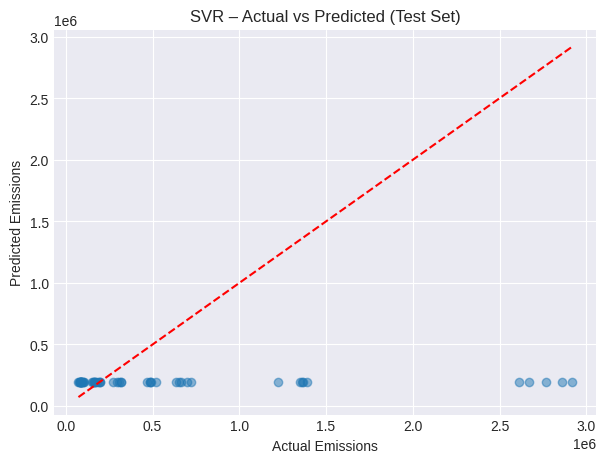

In [ ]:
plt.figure(figsize=(7,5))
plt.scatter(y_test, y_test_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual Emissions")
plt.ylabel("Predicted Emissions")
plt.title("SVR – Actual vs Predicted (Test Set)")
plt.show()


In [ ]:
from sklearn.inspection import permutation_importance


In [ ]:
print("\nCalculating SVR feature importance using permutation importance...")

perm_importance = permutation_importance(
    best_svr,                 # trained SVR model
    X_test_scaled,             # scaled test features
    y_test,                    # true target
    n_repeats=10,              # number of shuffles
    random_state=42,
    scoring='neg_mean_squared_error'
)



Calculating SVR feature importance using permutation importance...


In [ ]:
feature_importance_svr = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': perm_importance.importances_mean
}).sort_values('Importance', ascending=False)


In [ ]:
print("\nTop 15 Most Important Features (SVR):")
print(feature_importance_svr.head(15).to_string(index=False))



Top 15 Most Important Features (SVR):
               Feature   Importance
Country_Mean_Emissions 1.190279e+08
           Liquid Fuel 1.126201e+08
           Total_Lag_1 1.081195e+08
           Total_Lag_2 1.051131e+08
              Gas Fuel 1.025581e+08
           Total_Lag_3 9.905342e+07
 Country_Max_Emissions 8.396716e+07
           Gas Flaring 6.868703e+07
 Country_Std_Emissions 3.815865e+07
        Gas_Fuel_Ratio 3.207638e+07
       Country_Encoded 2.241723e+07
            Solid Fuel 1.940760e+07
      Solid_Fuel_Ratio 1.776780e+07
     Total_Growth_Rate 1.599520e+07
     Liquid_Fuel_Ratio 7.626787e+06


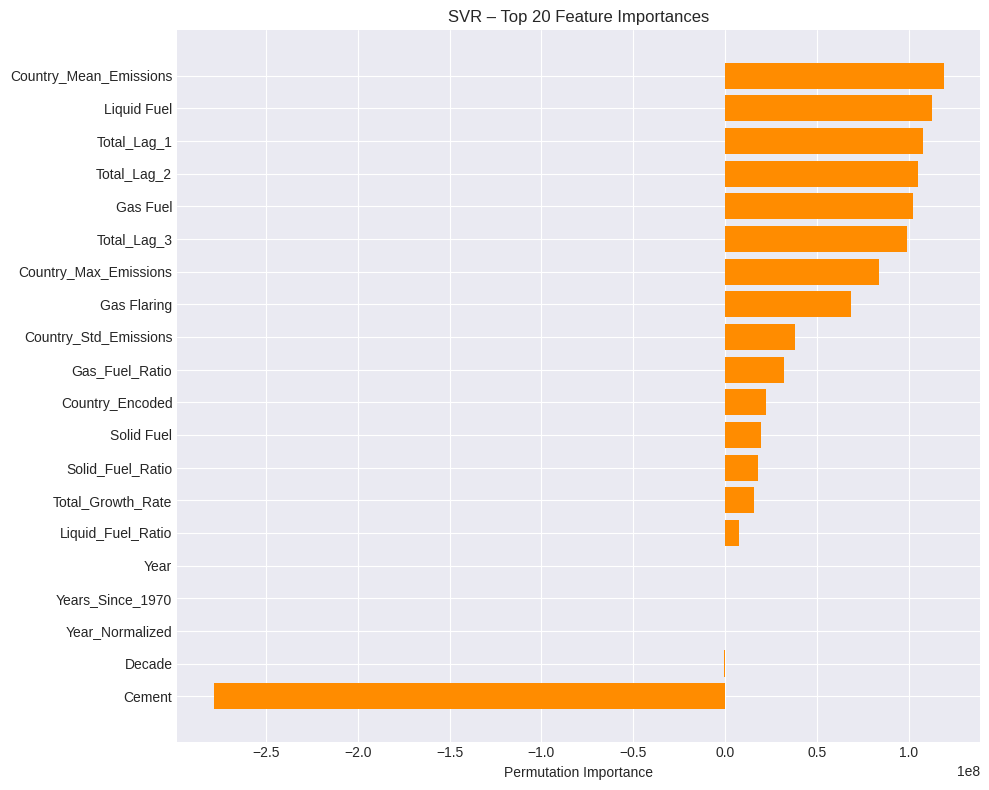

In [ ]:
plt.figure(figsize=(10, 8))

top_features_svr = feature_importance_svr.head(20)

plt.barh(
    range(len(top_features_svr)),
    top_features_svr['Importance'],
    color='darkorange'
)

plt.yticks(range(len(top_features_svr)), top_features_svr['Feature'])
plt.xlabel('Permutation Importance')
plt.title('SVR – Top 20 Feature Importances')
plt.gca().invert_yaxis()
plt.tight_layout()

plt.savefig('svr_feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()


In [ ]:
feature_importance_svr.to_csv('svr_feature_importance.csv', index=False)

print("\n✓ SVR feature importance saved!")



✓ SVR feature importance saved!


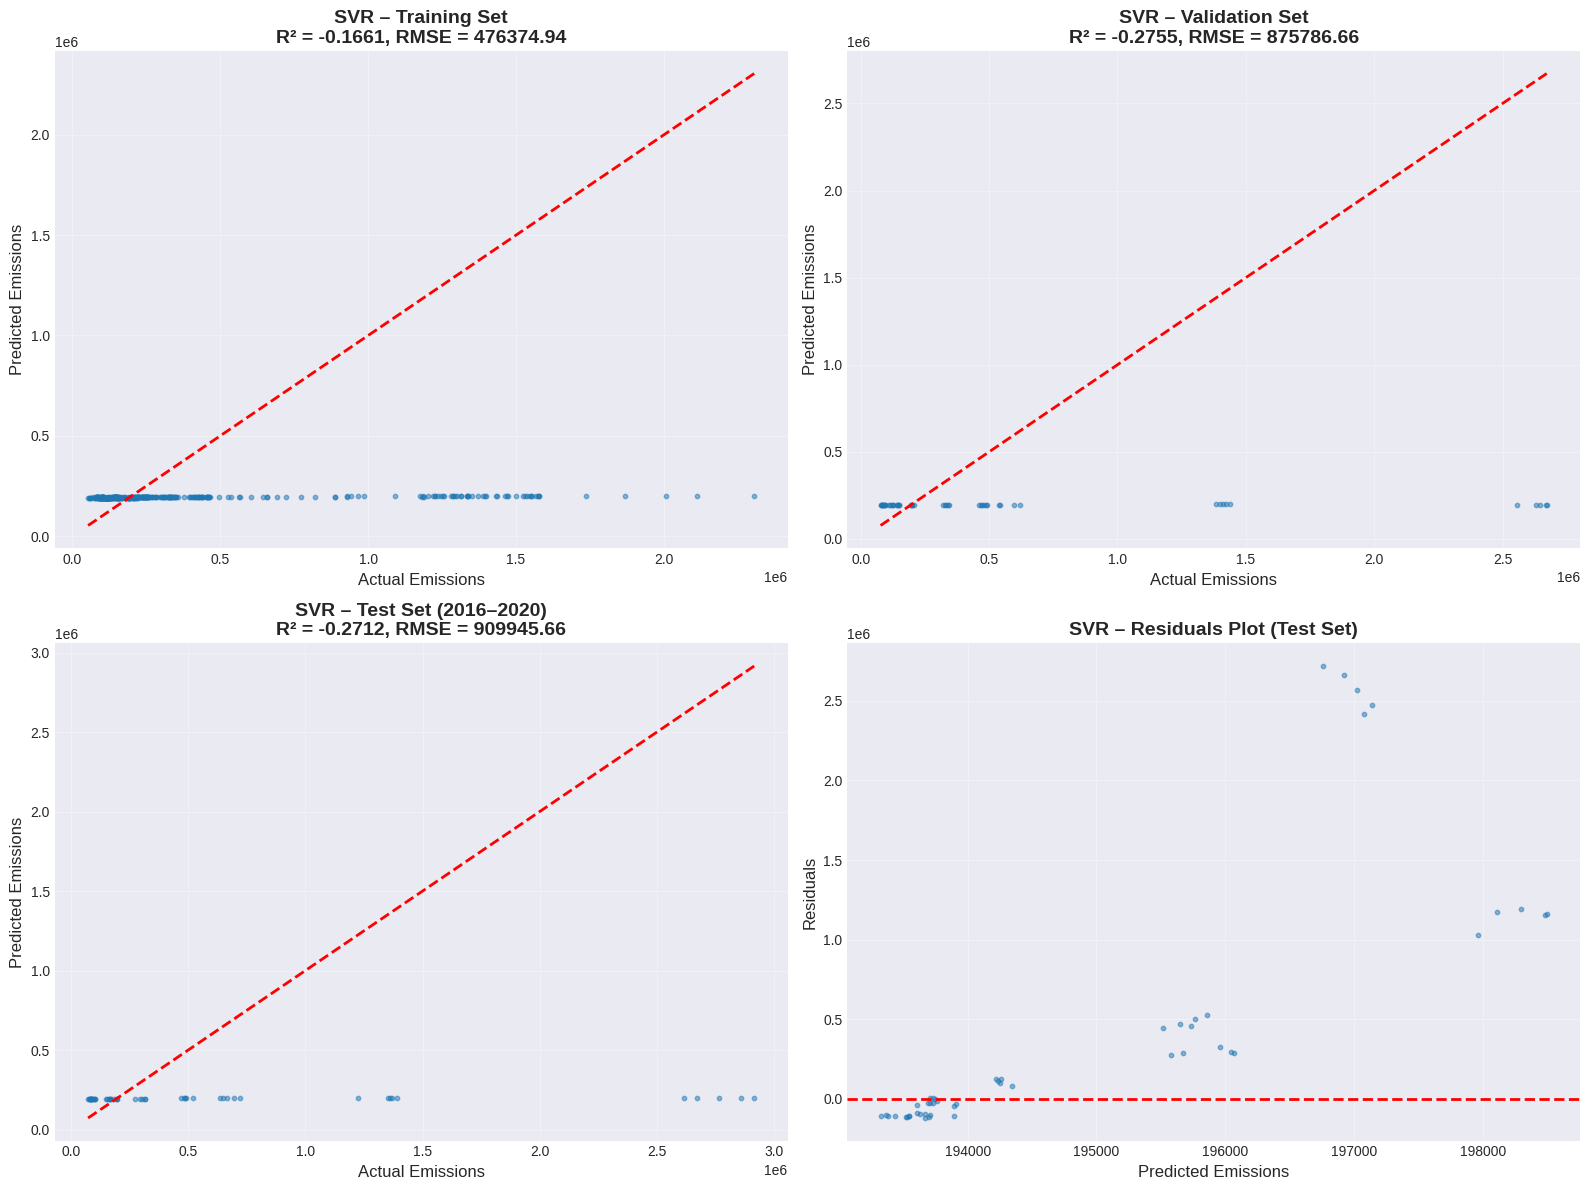


✓ SVR visualizations created and saved!


In [ ]:
# Create comprehensive visualization for SVR
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Training predictions
ax1 = axes[0, 0]
ax1.scatter(y_train, y_train_pred, alpha=0.5, s=10)
ax1.plot(
    [y_train.min(), y_train.max()],
    [y_train.min(), y_train.max()],
    'r--',
    lw=2
)
ax1.set_xlabel('Actual Emissions', fontsize=12)
ax1.set_ylabel('Predicted Emissions', fontsize=12)
ax1.set_title(
    f'SVR – Training Set\nR² = {metrics_svr["train"]["R2"]:.4f}, '
    f'RMSE = {metrics_svr["train"]["RMSE"]:.2f}',
    fontsize=14,
    fontweight='bold'
)
ax1.grid(True, alpha=0.3)

# 2. Validation predictions
ax2 = axes[0, 1]
ax2.scatter(y_val, y_val_pred, alpha=0.5, s=10)
ax2.plot(
    [y_val.min(), y_val.max()],
    [y_val.min(), y_val.max()],
    'r--',
    lw=2
)
ax2.set_xlabel('Actual Emissions', fontsize=12)
ax2.set_ylabel('Predicted Emissions', fontsize=12)
ax2.set_title(
    f'SVR – Validation Set\nR² = {metrics_svr["val"]["R2"]:.4f}, '
    f'RMSE = {metrics_svr["val"]["RMSE"]:.2f}',
    fontsize=14,
    fontweight='bold'
)
ax2.grid(True, alpha=0.3)

# 3. Test predictions
ax3 = axes[1, 0]
ax3.scatter(y_test, y_test_pred, alpha=0.5, s=10)
ax3.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--',
    lw=2
)
ax3.set_xlabel('Actual Emissions', fontsize=12)
ax3.set_ylabel('Predicted Emissions', fontsize=12)
ax3.set_title(
    f'SVR – Test Set (2016–2020)\nR² = {metrics_svr["test"]["R2"]:.4f}, '
    f'RMSE = {metrics_svr["test"]["RMSE"]:.2f}',
    fontsize=14,
    fontweight='bold'
)
ax3.grid(True, alpha=0.3)

# 4. Residuals plot
ax4 = axes[1, 1]
residuals_svr = y_test - y_test_pred
ax4.scatter(y_test_pred, residuals_svr, alpha=0.5, s=10)
ax4.axhline(y=0, color='r', linestyle='--', lw=2)
ax4.set_xlabel('Predicted Emissions', fontsize=12)
ax4.set_ylabel('Residuals', fontsize=12)
ax4.set_title('SVR – Residuals Plot (Test Set)', fontsize=14, fontweight='bold')
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('svr_predictions_comprehensive.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ SVR visualizations created and saved!")


In [ ]:
# FIX: Get Country from original top_10_df instead of df_features
# Create predictions dataframe for SVR
test_indices = df_features[test_mask].index

predictions_df_svr = pd.DataFrame({
    'Year': df_features.loc[test_indices, 'Year'],
    'Country': top_10_df.loc[test_indices, 'Country'],  # from original dataframe
    'Total': y_test.values,
    'Predicted': y_test_pred
})

predictions_df_svr['Error'] = predictions_df_svr['Total'] - predictions_df_svr['Predicted']
predictions_df_svr['Abs_Error'] = np.abs(predictions_df_svr['Error'])
predictions_df_svr['Pct_Error'] = (predictions_df_svr['Error'] / predictions_df_svr['Total']) * 100

In [ ]:
# Get the top 10 countries from the original data
top_10_countries = sorted(top_10_df['Country'].unique())

print(f"""
SUPPORT VECTOR REGRESSION (SVR) MODEL : TOP 10 CO2 EMITTERS


Dataset:

- Countries: {len(top_10_countries)}
- Top 10 Emitters: {', '.join(top_10_countries)}
- Total samples: {len(df_features):,}
- Features: {len(feature_cols)}
- Time period: 1970-2020

Best Hyperparameters:

{chr(10).join([f'- {k}: {v}' for k, v in random_search_svr.best_params_.items()])}

Performance Metrics:

Training Set (1970-2010):
  - RMSE: {metrics_svr['train']['RMSE']:.4f}
  - MAE: {metrics_svr['train']['MAE']:.4f}
  - R²: {metrics_svr['train']['R2']:.4f}

Validation Set (2011-2015):
  - RMSE: {metrics_svr['val']['RMSE']:.4f}
  - MAE: {metrics_svr['val']['MAE']:.4f}
  - R²: {metrics_svr['val']['R2']:.4f}

Test Set (2016-2020):
  - RMSE: {metrics_svr['test']['RMSE']:.4f}
  - MAE: {metrics_svr['test']['MAE']:.4f}
  - R²: {metrics_svr['test']['R2']:.4f}

Top 5 Most Important Features (Permutation Importance):

{chr(10).join([
    f'{i+1}. {row["Feature"]}: {row["Importance"]:.4f}'
    for i, row in feature_importance_svr.head(5).iterrows()
])}

Files Generated:

 svr_optimized.pkl - Trained SVR model
 feature_scaler_svr.pkl - Feature scaler
 country_encoder_svr.pkl - Country encoder
 svr_feature_importance.csv - Feature importance scores
 svr_feature_importance.png - Feature importance plot
 svr_predictions_comprehensive.png - Prediction plots
 svr_predictions_by_country.png - Country-wise predictions

 SUPPORT VECTOR REGRESSION TRAINING COMPLETE!
""")



SUPPORT VECTOR REGRESSION (SVR) MODEL : TOP 10 CO2 EMITTERS


Dataset:

- Countries: 10
- Top 10 Emitters: CANADA, CHINA (MAINLAND), FRANCE (INCLUDING MONACO), Germany, INDIA, JAPAN, POLAND, RUSSIAN FEDERATION, UNITED KINGDOM, UNITED STATES OF AMERICA
- Total samples: 488
- Features: 20
- Time period: 1970-2020

Best Hyperparameters:

- kernel: rbf
- gamma: 0.01
- epsilon: 0.01
- C: 100

Performance Metrics:

Training Set (1970-2010):
  - RMSE: 476374.9416
  - MAE: 254466.8767
  - R²: -0.1661

Validation Set (2011-2015):
  - RMSE: 875786.6647
  - MAE: 477238.4198
  - R²: -0.2755

Test Set (2016-2020):
  - RMSE: 909945.6572
  - MAE: 495135.1285
  - R²: -0.2712

Top 5 Most Important Features (Permutation Importance):

17. Country_Mean_Emissions: 119027873.1547
3. Liquid Fuel: 112620117.2804
13. Total_Lag_1: 108119508.3416
14. Total_Lag_2: 105113101.8814
4. Gas Fuel: 102558061.6334

Files Generated:

 svr_optimized.pkl - Trained SVR model
 feature_scaler_svr.pkl - Feature scaler
 country

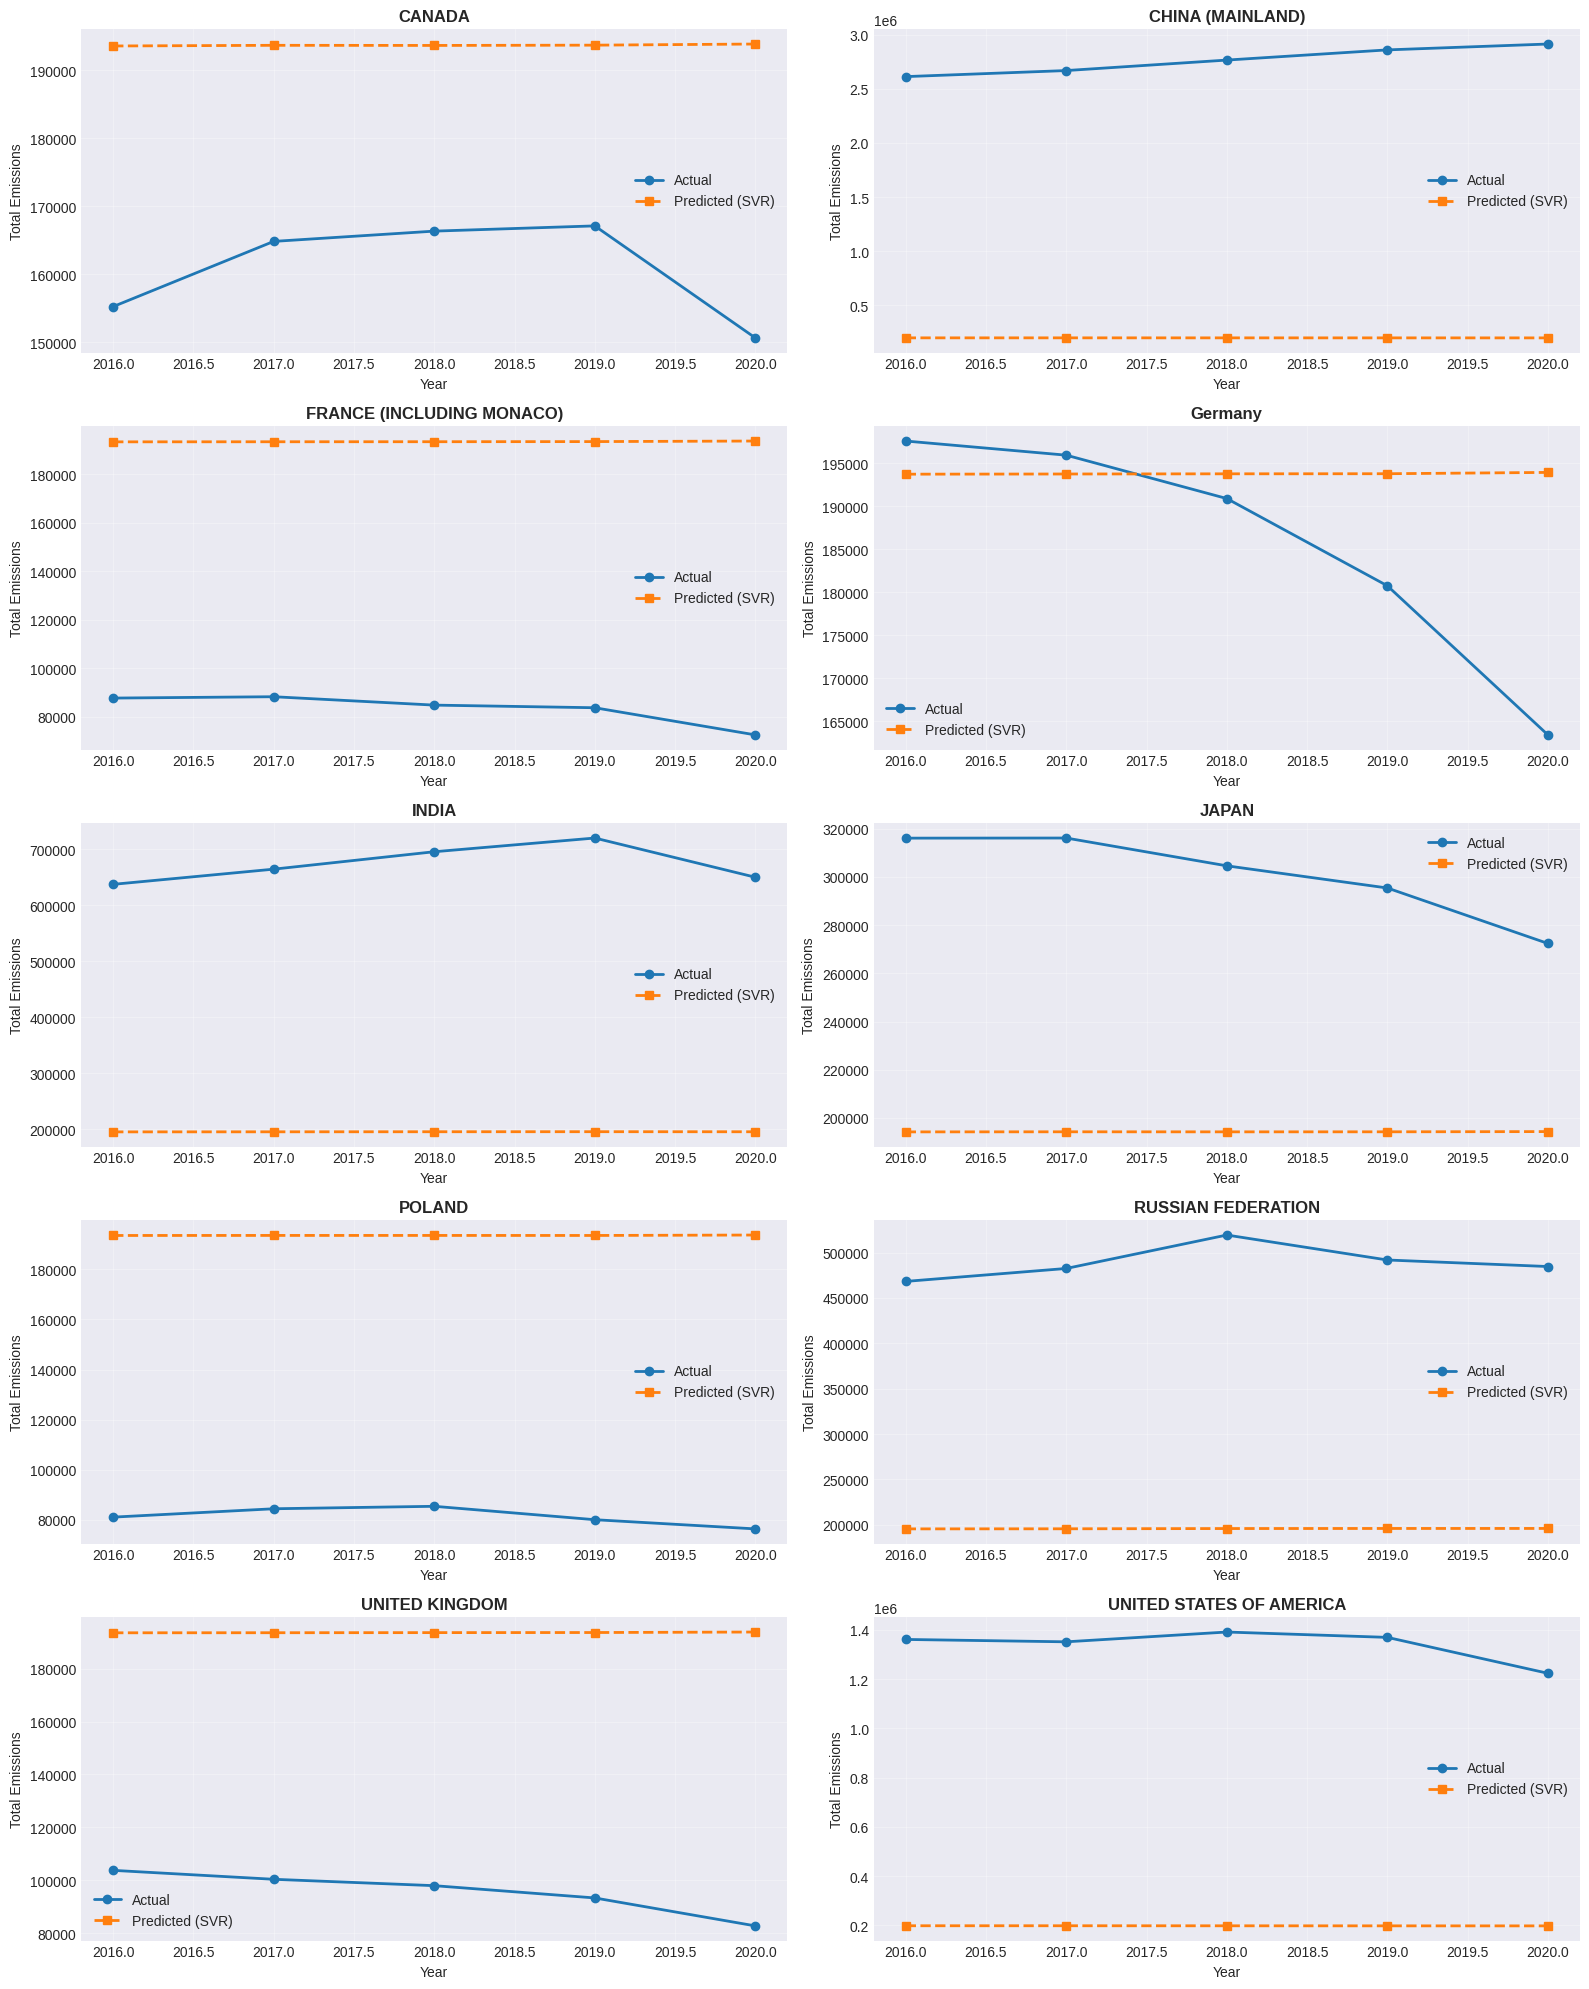

In [ ]:
countries = sorted(predictions_df_svr['Country'].unique())
fig, axes = plt.subplots(5, 2, figsize=(16, 20))
axes = axes.flatten()

for idx, country in enumerate(countries):
    country_data = predictions_df_svr[
        predictions_df_svr['Country'] == country
    ].sort_values('Year')

    ax = axes[idx]
    ax.plot(
        country_data['Year'],
        country_data['Total'],
        'o-',
        label='Actual',
        linewidth=2,
        markersize=6
    )
    ax.plot(
        country_data['Year'],
        country_data['Predicted'],
        's--',
        label='Predicted (SVR)',
        linewidth=2,
        markersize=6
    )

    ax.set_title(country, fontsize=12, fontweight='bold')
    ax.set_xlabel('Year')
    ax.set_ylabel('Total Emissions')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('svr_predictions_by_country.png', dpi=300, bbox_inches='tight')
plt.show()


## Ridge Regression

In [ ]:
# Download Necesary Libraries.
import pandas as pd
import numpy as np
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [ ]:
#Download Dataset.
carbon_dioxide_df = pd.read_csv("fossil-fuel-co2-emissions-by-nation.csv")
#Substract USSR Value.
carbon_dioxide_df = carbon_dioxide_df[carbon_dioxide_df["Country"] != "USSR"]
#Adding Germany Together:
mask = carbon_dioxide_df["Country"].str.contains("Germany", case=False, na=False)
carbon_dioxide_df.loc[mask, "Country"] = "Germany"

top_10_c02 = (
    carbon_dioxide_df.groupby("Country")["Total"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_10_df = carbon_dioxide_df[
    carbon_dioxide_df["Country"].isin(top_10_c02.index)
].reset_index(drop=True)

print("✓ Data loaded!")
print(f"Shape: {top_10_df.shape}")

✓ Data loaded!
Shape: (1764, 10)


In [ ]:
emission_cols = [
    'Solid Fuel', 'Liquid Fuel', 'Gas Fuel',
    'Cement', 'Gas Flaring', 'Bunker fuels (Not in Total)'
]

for col in emission_cols:
    if col in top_10_df.columns:
        top_10_df[col] = top_10_df[col].fillna(0)

top_10_df['Per Capita'] = top_10_df.groupby('Country')['Per Capita']\
    .transform(lambda x: x.fillna(x.median()))

top_10_df = top_10_df.dropna(subset=['Total'])

In [ ]:
top_10_df = top_10_df[
    (top_10_df['Year'] >= 1970) & (top_10_df['Year'] <= 2020)
]

top_10_df = top_10_df.sort_values(['Country', 'Year']).reset_index(drop=True)

print("✓ Data cleaned!")


✓ Data cleaned!


In [ ]:
#Feature Engeeniring:

#Most Relevant Features.
fe_vars = [
    "Total", "Solid Fuel", "Liquid Fuel",
    "Gas Fuel", "Cement", "Gas Flaring"
]

#Lags (1–3 años)
for var in fe_vars:
    for lag in [1, 2, 3]:
        top_10_df[f"{var}_Lag_{lag}"] = top_10_df.groupby("Country")[var].shift(lag)

#Medias móviles (3 y 5 años)
for var in fe_vars:
    for window in [3, 5]:
        top_10_df[f"{var}_RollingMean_{window}"] = (
            top_10_df.groupby("Country")[var]
              .rolling(window)
              .mean()
              .reset_index(0, drop=True)
        )


#Growth Rate
for var in fe_vars:
    top_10_df[f"{var}_GrowthRate"] = top_10_df.groupby("Country")[var].pct_change()

#Ratios de combustibles (solo los que están en Total)
top_10_df["SolidFuel_Ratio"]  = top_10_df["Solid Fuel"]  / top_10_df["Total"]
top_10_df["LiquidFuel_Ratio"] = top_10_df["Liquid Fuel"] / top_10_df["Total"]
top_10_df["GasFuel_Ratio"]    = top_10_df["Gas Fuel"]    / top_10_df["Total"]
top_10_df["Cement_Ratio"]     = top_10_df["Cement"]      / top_10_df["Total"]
top_10_df["Flaring_Ratio"]    = top_10_df["Gas Flaring"] / top_10_df["Total"]

#Temporal Features:
top_10_df["Years_Since_1970"] = top_10_df["Year"] - 1970
top_10_df["Decade"] = (top_10_df["Year"] // 10) * 10

#Eliminate Nan Values:
top_10_df = top_10_df.dropna()

print(top_10_df.shape)

top_10_df.head()

(299, 53)


,Year,Country,Total,Solid Fuel,Liquid Fuel,Gas Fuel,Cement,Gas Flaring,Per Capita,Bunker fuels (Not in Total),Total_Lag_1,Total_Lag_2,Total_Lag_3,Solid Fuel_Lag_1,Solid Fuel_Lag_2,Solid Fuel_Lag_3,Liquid Fuel_Lag_1,Liquid Fuel_Lag_2,Liquid Fuel_Lag_3,Gas Fuel_Lag_1,Gas Fuel_Lag_2,Gas Fuel_Lag_3,Cement_Lag_1,Cement_Lag_2,Cement_Lag_3,Gas Flaring_Lag_1,Gas Flaring_Lag_2,Gas Flaring_Lag_3,Total_RollingMean_3,Total_RollingMean_5,Solid Fuel_RollingMean_3,Solid Fuel_RollingMean_5,Liquid Fuel_RollingMean_3,Liquid Fuel_RollingMean_5,Gas Fuel_RollingMean_3,Gas Fuel_RollingMean_5,Cement_RollingMean_3,Cement_RollingMean_5,Gas Flaring_RollingMean_3,Gas Flaring_RollingMean_5,Total_GrowthRate,Solid Fuel_GrowthRate,Liquid Fuel_GrowthRate,Gas Fuel_GrowthRate,Cement_GrowthRate,Gas Flaring_GrowthRate,SolidFuel_Ratio,LiquidFuel_Ratio,GasFuel_Ratio,Cement_Ratio,Flaring_Ratio,Years_Since_1970,Decade
4,1974,CANADA,106346,13239.0,67938.0,22794.0,1411.0,965.0,4.695326,2914.0,104069.0,103937.0,96157.0,14196.0,16964.0,15250.0,65004.0,63679.0,60133.0,22344.0,20875.0,18414.0,1373.0,1231.0,1119.0,1152.0,1189.0,1241.0,104784.000000,100726.6,14799.666667,15140.2,65540.333333,62888.6,22004.333333,20303.8,1338.333333,1222.8,1102.000000,1171.6,0.021880,-0.067413,0.045136,0.020140,0.027677,-0.162326,0.124490,0.638839,0.214338,0.013268,0.009074,4,1970
5,1975,CANADA,108302,16726.0,66044.0,23448.0,1355.0,728.0,4.713800,2416.0,106346.0,104069.0,103937.0,13239.0,14196.0,16964.0,67938.0,65004.0,63679.0,22794.0,22344.0,20875.0,1411.0,1373.0,1231.0,965.0,1152.0,1189.0,106239.000000,103762.2,14720.333333,15275.0,66328.666667,64559.6,22862.000000,21575.0,1379.666667,1297.8,948.333333,1055.0,0.018393,0.263388,-0.027878,0.028692,-0.039688,-0.245596,0.154439,0.609813,0.216506,0.012511,0.006722,5,1970
6,1976,CANADA,108895,16130.0,63792.0,27000.0,1309.0,664.0,4.674217,2350.0,108302.0,106346.0,104069.0,16726.0,13239.0,14196.0,66044.0,67938.0,65004.0,23448.0,22794.0,22344.0,1355.0,1411.0,1373.0,728.0,965.0,1152.0,107847.666667,106309.8,15365.000000,15451.0,65924.666667,65291.4,24414.000000,23292.2,1358.333333,1335.8,785.666667,939.6,0.005475,-0.035633,-0.034098,0.151484,-0.033948,-0.087912,0.148124,0.585812,0.247945,0.012021,0.006098,6,1970
7,1977,CANADA,111304,17749.0,63783.0,27826.0,1311.0,635.0,4.718813,2308.0,108895.0,108302.0,106346.0,16130.0,16726.0,13239.0,63792.0,66044.0,67938.0,27000.0,23448.0,22794.0,1309.0,1355.0,1411.0,664.0,728.0,965.0,109500.333333,107783.2,16868.333333,15608.0,64539.666667,65312.2,26091.333333,24682.4,1325.000000,1351.8,675.666667,828.8,0.022122,0.100372,-0.000141,0.030593,0.001528,-0.043675,0.159464,0.573052,0.250000,0.011779,0.005705,7,1970
8,1978,CANADA,113416,18971.0,63817.0,28535.0,1403.0,691.0,4.756703,2580.0,111304.0,108895.0,108302.0,17749.0,16130.0,16726.0,63783.0,63792.0,66044.0,27826.0,27000.0,23448.0,1311.0,1309.0,1355.0,635.0,664.0,728.0,111205.000000,109652.6,17616.666667,16563.0,63797.333333,65074.8,27787.000000,25920.6,1341.000000,1357.8,663.333333,736.6,0.018975,0.068849,0.000533,0.025480,0.070175,0.088189,0.167269,0.562681,0.251596,0.012370,0.006093,8,1970


In [ ]:
#Defining Main Features and Target
target = "Total"

# Excluir columnas no numéricas y el target
feature_cols = [
    col for col in top_10_df.columns
    if col not in ["Country", "Year", "Total"]
]

X = top_10_df[feature_cols]
y = top_10_df[target]

In [ ]:
#Split temporal: train / valid / test
train = top_10_df[top_10_df["Year"] <= 2010]
valid = top_10_df[(top_10_df["Year"] > 2010) & (top_10_df["Year"] <= 2015)]
test  = top_10_df[top_10_df["Year"] > 2015]

X_train, y_train = train[feature_cols], train[target]
X_valid, y_valid = valid[feature_cols], valid[target]
X_test,  y_test  = test[feature_cols],  test[target]

In [ ]:
#Pipeline Ridge Regression
ridge_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("ridge", Ridge())
])

#Search hyperparámetres (alpha)
param_grid = {
    "ridge__alpha": [0.01, 0.1, 1, 10, 50, 100, 200]
}

tscv = TimeSeriesSplit(n_splits=3)

grid = GridSearchCV(
    ridge_pipeline,
    param_grid,
    cv=tscv,
    scoring="neg_mean_squared_error"
)

# Replace infinite values with NaN and drop corresponding rows to prevent ValueError
X_train = X_train.replace([np.inf, -np.inf], np.nan).dropna()
y_train = y_train.loc[X_train.index] # Ensure y_train matches the cleaned X_train index

grid.fit(X_train, y_train)
best_model = grid.best_estimator_

print("Best alpha:", grid.best_params_["ridge__alpha"])

Best alpha: 0.01


In [ ]:
#Evaluation in valid and test
y_pred_valid = best_model.predict(X_valid)
y_pred_test  = best_model.predict(X_test)

val_rmse = np.sqrt(mean_squared_error(y_valid, y_pred_valid))
test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
test_mae  = mean_absolute_error(y_test, y_pred_test)
test_r2   = r2_score(y_test, y_pred_test)

print("Validation RMSE:", val_rmse)
print("Test RMSE:", test_rmse)
print("Test MAE:", test_mae)
print("Test R2:", test_r2)

Validation RMSE: 1046.4242265888906
Test RMSE: 999.7805741168065
Test MAE: 639.0127441088777
Test R2: 0.9999944483759733


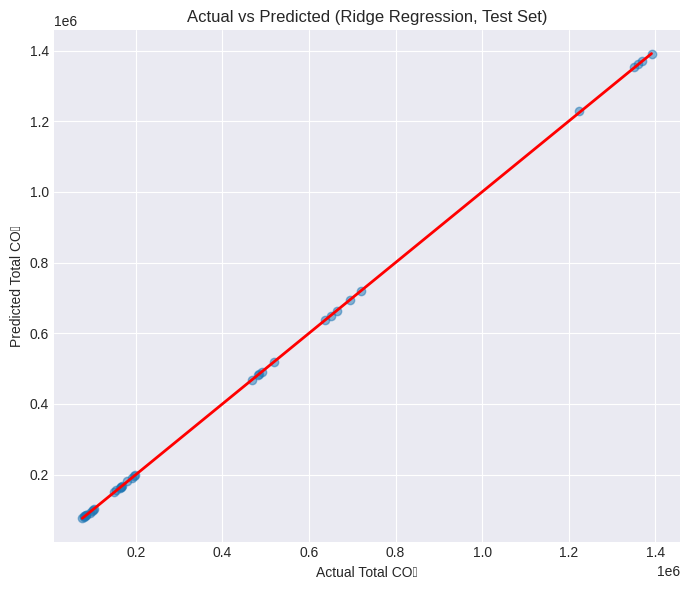

In [ ]:
#Actual vs Predictive
plt.figure(figsize=(7, 6))
plt.scatter(y_test, y_pred_test, alpha=0.5)
min_val = min(y_test.min(), y_pred_test.min())
max_val = max(y_test.max(), y_pred_test.max())
plt.plot([min_val, max_val], [min_val, max_val], color="red", linewidth=2)
plt.xlabel("Actual Total CO₂")
plt.ylabel("Predicted Total CO₂")
plt.title("Actual vs Predicted (Ridge Regression, Test Set)")
plt.tight_layout()
plt.show()

In [ ]:
#Importancia / interpretación de coeficientes
coef = best_model.named_steps["ridge"].coef_
importance_df = pd.DataFrame({
    "Feature": feature_cols,
    "Coefficient": coef
})

importance_df_sorted = importance_df.sort_values(
    by="Coefficient", ascending=False
)

importance_df_sorted.head(20)


,Feature,Coefficient
1,Liquid Fuel,165520.888937
0,Solid Fuel,137534.448143
2,Gas Fuel,89365.443112
29,Liquid Fuel_RollingMean_3,46292.805531
25,Total_RollingMean_3,40097.389310
27,Solid Fuel_RollingMean_3,38750.252876
31,Gas Fuel_RollingMean_3,23452.666328
30,Liquid Fuel_RollingMean_5,8376.965486
3,Cement,7760.134493
26,Total_RollingMean_5,7108.987638


In [ ]:
# 1. SAVE TOP_10_DF (Full dataset with all years)
top_10_df.to_csv('top_10_emissions_full.csv', index=False)
print("✓ Saved: top_10_emissions_full.csv")

# 2. SAVE MODEL PERFORMANCE METRICS
model_metrics = pd.DataFrame({
    'Dataset': ['Training', 'Validation', 'Test'],
    'RMSE': [
        metrics_rf['train']['RMSE'],
        metrics_rf['val']['RMSE'],
        metrics_rf['test']['RMSE']
    ],
    'MAE': [
        metrics_rf['train']['MAE'],
        metrics_rf['val']['MAE'],
        metrics_rf['test']['MAE']
    ],
    'R2': [
        metrics_rf['train']['R2'],
        metrics_rf['val']['R2'],
        metrics_rf['test']['R2']
    ]
})
model_metrics.to_csv('rf_model_metrics.csv', index=False)
print("✓ Saved: rf_model_metrics.csv")

# 3. SAVE COUNTRY SUMMARY STATISTICS
country_summary = top_10_df.groupby('Country').agg({
    'Total': ['mean', 'max', 'min', 'std'],
    'Year': 'count'
}).reset_index()
country_summary.columns = ['Country', 'Avg_Emissions', 'Max_Emissions',
                            'Min_Emissions', 'Std_Emissions', 'Years_Count']
country_summary = country_summary.round(2)
country_summary.to_csv('country_summary.csv', index=False)
print("✓ Saved: country_summary.csv")

# 4. SAVE YEARLY AGGREGATES (for trends)
yearly_totals = top_10_df.groupby('Year').agg({
    'Total': 'sum',
    'Solid Fuel': 'sum',
    'Liquid Fuel': 'sum',
    'Gas Fuel': 'sum',
    'Country': 'count'
}).reset_index()
yearly_totals.columns = ['Year', 'Total_Emissions', 'Solid_Fuel',
                         'Liquid_Fuel', 'Gas_Fuel', 'Num_Countries']
yearly_totals.to_csv('yearly_emissions.csv', index=False)
print("✓ Saved: yearly_emissions.csv")

# 5. SAVE PREDICTIONS WITH ERROR CATEGORIES (for better visuals)
predictions_enhanced = predictions_df.copy()
predictions_enhanced['Error_Category'] = pd.cut(
    predictions_enhanced['Abs_Error'],
    bins=[0, 20, 50, 100, 1000],
    labels=['Excellent (<20)', 'Good (20-50)', 'Fair (50-100)', 'Poor (>100)']
)
predictions_enhanced['Overpredict'] = predictions_enhanced['Error'] < 0
predictions_enhanced.to_csv('rf_predictions_enhanced.csv', index=False)
print("✓ Saved: rf_predictions_enhanced.csv")

print("\n" + "="*70)
print("ALL FILES READY FOR POWER BI!")
print("="*70)
print("\nDownload these 6 files:")
print("1. top_10_emissions_full.csv")
print("2. rf_model_metrics.csv")
print("3. country_summary.csv")
print("4. yearly_emissions.csv")
print("5. rf_feature_importance.csv (already have)")
print("6. rf_predictions_enhanced.csv")

✓ Saved: top_10_emissions_full.csv
✓ Saved: rf_model_metrics.csv
✓ Saved: country_summary.csv
✓ Saved: yearly_emissions.csv
✓ Saved: rf_predictions_enhanced.csv

ALL FILES READY FOR POWER BI!

Download these 6 files:
1. top_10_emissions_full.csv
2. rf_model_metrics.csv
3. country_summary.csv
4. yearly_emissions.csv
5. rf_feature_importance.csv (already have)
6. rf_predictions_enhanced.csv


In [ ]:
%matplotlib inline

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from xgboost import XGBRegressor, plot_importance
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


In [ ]:
# Ensure correct column names
df = df.sort_values(["country", "year"]).reset_index(drop=True)

df["log_co2"] = np.log1p(df["co2"])

for lag in [1, 2, 3]:
    df[f"lag_{lag}"] = df.groupby("country")["log_co2"].shift(lag)

df = df.dropna()


NameError: name 'df' is not defined

In [ ]:
features = ["lag_1", "lag_2", "lag_3"]
target = "log_co2"

train = df[df["year"] <= 2015]
test  = df[df["year"] > 2015]

X_train = train[features]
y_train = train[target]

X_test  = test[features]
y_test  = test[target]


In [ ]:
xgb_model = XGBRegressor(
    n_estimators=400,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)


In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

mse = mean_squared_error(y_test, y_pred_xgb)
rmse = np.sqrt(mse)
mae  = mean_absolute_error(y_test, y_pred_xgb)
r2   = r2_score(y_test, y_pred_xgb)

print("XGBoost Performance")
print("-------------------")
print(f"RMSE : {rmse:.4f}")
print(f"MAE  : {mae:.4f}")
print(f"R²   : {r2:.4f}")


In [ ]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred_xgb, alpha=0.5)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red"
)
plt.xlabel("Actual CO₂ (log)")
plt.ylabel("Predicted CO₂ (log)")
plt.title("XGBoost: Actual vs Predicted")
plt.show()


In [ ]:
residuals = y_test - y_pred_xgb

plt.figure(figsize=(6,4))
sns.histplot(residuals, kde=True)
plt.title("XGBoost Residual Distribution")
plt.xlabel("Residuals")
plt.show()


In [ ]:
plt.figure(figsize=(6,4))
plt.scatter(y_pred_xgb, residuals, alpha=0.5)
plt.axhline(0, color="red")
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residuals vs Predicted (XGBoost)")
plt.show()


In [ ]:
plt.figure(figsize=(6,4))
plot_importance(
    xgb_model,
    max_num_features=10,
    importance_type="gain"
)
plt.title("Top 10 Feature Importances (XGBoost)")
plt.show()


In [ ]:
plt.figure(figsize=(10,4))
plt.plot(y_test.values[:200], label="Actual")
plt.plot(y_pred_xgb[:200], label="Predicted")
plt.title("XGBoost: Actual vs Predicted (Time Series)")
plt.legend()
plt.show()


In [ ]:
%matplotlib inline

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.callbacks import EarlyStopping

import warnings
warnings.filterwarnings("ignore")


In [ ]:
# Load dataset
df = pd.read_csv("fossil-fuel-co2-emissions-by-nation-JS1gcZ.csv")

# Rename columns
df = df.rename(columns={
    "Country": "country",
    "Year": "year",
    "Total": "co2"
})

df = df[["country", "year", "co2"]]
df = df.dropna()
df = df[df["co2"] > 0]

# Sort for time series
df = df.sort_values(["country", "year"]).reset_index(drop=True)

print(df.head())


In [ ]:
# Log transform
df["log_co2"] = np.log1p(df["co2"])

# Create lag features
for lag in [1, 2, 3]:
    df[f"lag_{lag}"] = df.groupby("country")["log_co2"].shift(lag)

df = df.dropna()


In [ ]:
features = ["lag_1", "lag_2", "lag_3"]
target = "log_co2"

train = df[df["year"] <= 2015]
test  = df[df["year"] > 2015]

X_train = train[features].values
y_train = train[target].values

X_test  = test[features].values
y_test  = test[target].values


In [ ]:
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled  = scaler_X.transform(X_test)

y_train_scaled = scaler_y.fit_transform(y_train.reshape(-1, 1))
y_test_scaled  = scaler_y.transform(y_test.reshape(-1, 1))


In [ ]:
X_train_lstm = X_train_scaled.reshape(
    (X_train_scaled.shape[0], 1, X_train_scaled.shape[1])
)

X_test_lstm = X_test_scaled.reshape(
    (X_test_scaled.shape[0], 1, X_test_scaled.shape[1])
)


In [ ]:
model = Sequential()
model.add(LSTM(50, activation="tanh", input_shape=(1, X_train_lstm.shape[2])))
model.add(Dense(1))

model.compile(
    optimizer="adam",
    loss="mse"
)

model.summary()


In [ ]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

history = model.fit(
    X_train_lstm,
    y_train_scaled,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)


In [ ]:
y_pred_scaled = model.predict(X_test_lstm)

y_pred_lstm = scaler_y.inverse_transform(y_pred_scaled).flatten()
y_test_inv  = scaler_y.inverse_transform(y_test_scaled).flatten()


In [ ]:
mse  = mean_squared_error(y_test_inv, y_pred_lstm)
rmse = np.sqrt(mse)
mae  = mean_absolute_error(y_test_inv, y_pred_lstm)
r2   = r2_score(y_test_inv, y_pred_lstm)

print("LSTM Performance")
print("----------------")
print(f"RMSE : {rmse:.4f}")
print(f"MAE  : {mae:.4f}")
print(f"R²   : {r2:.4f}")


In [ ]:
plt.figure(figsize=(6,6))
plt.scatter(y_test_inv, y_pred_lstm, alpha=0.5)
plt.plot(
    [y_test_inv.min(), y_test_inv.max()],
    [y_test_inv.min(), y_test_inv.max()],
    color="red"
)
plt.xlabel("Actual CO₂ (log)")
plt.ylabel("Predicted CO₂ (log)")
plt.title("LSTM: Actual vs Predicted")
plt.show()


In [ ]:
plt.figure(figsize=(12,4))
plt.plot(y_test_inv[:200], label="Actual")
plt.plot(y_pred_lstm[:200], label="Predicted")
plt.title("LSTM Actual vs Predicted (Time Series)")
plt.legend()
plt.show()


In [ ]:
residuals = y_test_inv - y_pred_lstm

plt.figure(figsize=(6,4))
sns.histplot(residuals, kde=True)
plt.title("LSTM Residual Distribution")
plt.show()


In [ ]:
plt.figure(figsize=(6,4))
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("MSE Loss")
plt.title("LSTM Training History")
plt.legend()
plt.show()
